# Lecture 3: Convolutional Neural Networks and Segmentation & Detection
Welcome to this hands-on tutorial on **Convolutional Neural Networks (CNNs)**, a transformative innovation in deep learning that has revolutionized computer vision tasks. In this notebook, we’ll explore the fundamental building blocks of CNNs and their applications in **image segmentation**, a task that involves classifying each pixel in an image into meaningful categories.

CNNs are particularly well-suited for computer vision tasks due to their ability to learn spatial hierarchies of features, such as edges, textures, and object parts, by applying convolutional filters. These filters act as feature extractors, identifying patterns in local regions of an image.

By the end of this notebook, you’ll understand how to:

1) Visualize convolutional filters and grasp their role in feature extraction.
2) Build and train a basic CNN model using PyTorch.
3) Implement your first segmentation model and evaluate its performance on a dataset.

Our journey begins with understanding the motivation behind CNNs and why they outperform traditional Multi-Layer Perceptrons (MLPs) for image analysis tasks. Next, we'll dive into the implementation of a segmentation pipeline, showcasing the practical power of CNNs.

Let’s get started!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np



## Step 1: Understand the limitations of general MLPs
In this section, we'll revisit the constraints inherent in general MLPs. We'll start by defining an MLP class and then explore the consequences when attempting to increase the number of hidden layers.

In [3]:
# Function to create a Multi-Layer Perceptron (MLP)
class MLP(nn.Module):
    def __init__(self, num_hidden_layers, hidden_layer_size):
        super(MLP, self).__init__()
        layers_list = []
        layers_list.append(nn.Flatten())      

        for i in range(num_hidden_layers):
            if i == 0: # create first layers
                layers_list.append(nn.Linear(32*32*1, hidden_layer_size)) # 32*32*3 = cifar image x,y size and RGB channels
            else:
                layers_list.append(nn.Linear(hidden_layer_size, hidden_layer_size))
                
            layers_list.append(nn.ReLU())

        # Output layer
        layers_list.append(nn.Linear(hidden_layer_size, 10))  # Assuming 10 classes for CIFAR-10

        self.mlp = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.mlp(x)
    
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [4]:
num_hidden_layers_list = [1, 2, 5, 10,]
hidden_layer_size = 64


# Loop through different numbers of hidden layers
for num_hidden_layers in num_hidden_layers_list:
    # Create and train the model
    model = MLP(num_hidden_layers, hidden_layer_size)
    
    # Count the number of parameters
    num_params = count_parameters(model)
    print(f"Number of parameters for {num_hidden_layers}-layer MLP: {num_params}")


Number of parameters for 1-layer MLP: 66250
Number of parameters for 2-layer MLP: 70410
Number of parameters for 5-layer MLP: 82890
Number of parameters for 10-layer MLP: 103690


You can clearly see that the number of **trainable parameters** increases heavily with an increase in hidden layers. Now let's train these different models!

In [5]:
def train_model(model, train_loader, num_epochs=5, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}')

def test_model(model, test_loader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs, labels  # Assuming you're using GPU
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print('Accuracy on the test set: {:.2f}%'.format(accuracy))
        

We will make use of the same dataset used in the first notebook, CIFAR-10. However to make the next part about convolutions a bit more intuitive we will transform the images to 1-channel grayscale images.

In [6]:
transform = transforms.Compose([    
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),# Converts to grayscale
      
])

cifar_train = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=10,
                                          shuffle=True, num_workers=2)

cifar_test = datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(cifar_test, batch_size=10,
                                          shuffle=False, num_workers=2)


c:\Users\20192478\AppData\Local\miniconda3\envs\NNforCV\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [7]:
import time

learning_rate = 0.01
nb_epochs = 10

for num_hidden_layers in num_hidden_layers_list:
    
    # Create and train the model
    model = MLP(num_hidden_layers, hidden_layer_size)
    # Count the number of parameters
    num_params = count_parameters(model)
    print(f"Number of parameters for {num_hidden_layers}-layer MLP: {num_params}")
    
    # Start model training 
    start_time = time.time()
    train_model(model, trainloader, nb_epochs, learning_rate)
    end_time = time.time()
       
    execution_time = end_time - start_time
    print(f"Time taken for {num_hidden_layers}-layer MLP: {execution_time:.2f} seconds")
    
    # Test model
    test_model(model, testloader)

Number of parameters for 1-layer MLP: 66250
Epoch 1/10, Loss: 2.1597
Epoch 2/10, Loss: 2.1305
Epoch 3/10, Loss: 2.1178
Epoch 4/10, Loss: 2.1027
Epoch 5/10, Loss: 2.0872
Epoch 6/10, Loss: 2.0703
Epoch 7/10, Loss: 2.0547
Epoch 8/10, Loss: 2.0447
Epoch 9/10, Loss: 2.0362
Epoch 10/10, Loss: 2.0366
Time taken for 1-layer MLP: 216.66 seconds
Accuracy on the test set: 23.01%
Number of parameters for 2-layer MLP: 70410
Epoch 1/10, Loss: 2.0923
Epoch 2/10, Loss: 2.0308
Epoch 3/10, Loss: 2.0175
Epoch 4/10, Loss: 2.0046
Epoch 5/10, Loss: 1.9959
Epoch 6/10, Loss: 1.9783
Epoch 7/10, Loss: 1.9638
Epoch 8/10, Loss: 1.9602
Epoch 9/10, Loss: 1.9484
Epoch 10/10, Loss: 1.9453
Time taken for 2-layer MLP: 227.85 seconds
Accuracy on the test set: 30.65%
Number of parameters for 5-layer MLP: 82890
Epoch 1/10, Loss: 2.1312
Epoch 2/10, Loss: 2.0166
Epoch 3/10, Loss: 1.9723
Epoch 4/10, Loss: 1.9406
Epoch 5/10, Loss: 1.9154
Epoch 6/10, Loss: 1.9032
Epoch 7/10, Loss: 1.8940
Epoch 8/10, Loss: 1.8867
Epoch 9/10, Lo

## Questions
**Q1**. What happens to the training time when you increase the number of hidden layers?

There is very little time difference when increasing the number of layers. It seems to be almost independent of the number of layers, which is unexpected.
- Time taken for 1-layer MLP: 336.86 seconds
- Time taken for 2-layer MLP: 369.34 seconds
- Time taken for 5-layer MLP: 370.09 seconds
- Time taken for 10-layer MLP: 355.37 seconds

**Q2**. How does the loss change with an increase in hidden layers?

At 1 layer, and 10 layers, the loss is going down very slowely. at 2 layers the loss is going down a bit faster, 5 layers seems to be the optimal amount of layers, since the loss is decreasing here most efficiently

**Q3**. Why do you think the accuracy of the model decreases for the 10 layer MLP?

The model is overfitting on the training data? The model gives a copletely random result

## Step 2: Implement Convolutional Filters
First, let's observe how an image transforms after applying a convolutional filter. Experiment with defining at least three general convolutional filters and observe the resulting images after applying these filters.

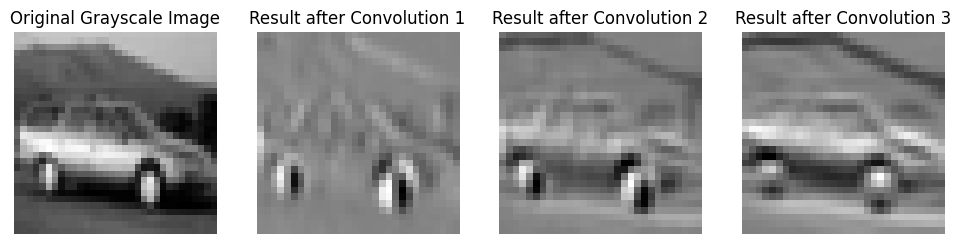

In [8]:
# Set up a transform to convert images to tensors and grayscale
transform = transforms.Compose([    
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1), # Converts to grayscale
      
])

# Load a single grayscale image
cifar_train = datasets.CIFAR10(root='./data', train=True,
                                download=True, transform=transform)

image, label = cifar_train[4]
gray_image = image.squeeze().numpy()

# Function to apply 2D convolution with multiple filters
def apply_convolutions(image, kernels):
    image_tensor = torch.tensor(image).unsqueeze(0).unsqueeze(0).float()
    results = [F.conv2d(image_tensor, kernel.unsqueeze(0).unsqueeze(0).float(), padding=0).squeeze().numpy() for kernel in kernels]
    return results

# Function to display images
def display_images(images, titles):
    plt.figure(figsize=(len(images) * 3, 3))
    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

# Define multiple convolutional filters (kernels), these should be a 2x2 or 3x3 pytorch tensor
kernels = [
    torch.tensor([
        [-1,  0,  1],
        [-2,  0,  2],
        [-1,  0,  1]
    ], dtype=torch.float32),   # Sobel filter for horizontal edges

    torch.tensor([
        [-2, -1, 0],
        [-1,  0, 1],
        [0,   1, 2]
    ], dtype=torch.float32),   # Diagonal filter

    torch.tensor([
        [-1,  -1,  -1],
        [0,  0,     0],
        [1,  1,     1]
    ], dtype=torch.float32)]   # Vertical edge filter


# Apply 2D convolution with multiple filters
results = apply_convolutions(gray_image, kernels)

# Display original image and results
display_images([gray_image] + results, ['Original Grayscale Image'] + ['Result after Convolution {}'.format(i+1) for i in range(len(results))])


Now, attempt to implement a basic CNN architecture. Refer to the lecture slides for guidance on its structure and components.

In [9]:
# Define the SimpleCNN model, for visualization purpose please refer to the first convolutional layer as conv1.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # TODO: (1) make a CNN classification model consiting out of at least 3 convolutional building blocks. (2) the first convolutional
        # layers should be refered to as self.conv1 for visualization purpose. (3) the output layer that returns the output 
        # for the 10 classes (NOTE: we flatten the images; see forward function)
            # Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Downsample
        self.pool = nn.MaxPool2d(2)  # 32->16->8->4

        # Efficient head: global average pooling -> small linear
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # (B, 64, 1, 1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.gap(x)                 # (B, 64, 1, 1)
        x = x.flatten(1)                # (B, 64)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [10]:
simple_cnn = SimpleCNN()
nb_epochs = 10
learning_rate = 0.01

# Create and train the model
num_params = count_parameters(simple_cnn)
print(f"Number of parameters for CNN: {num_params}")

# Start model training 
train_model(simple_cnn, trainloader, nb_epochs, learning_rate)
test_model(simple_cnn, testloader)

Number of parameters for CNN: 24170
Epoch 1/10, Loss: 1.6750
Epoch 2/10, Loss: 1.4095
Epoch 3/10, Loss: 1.3064
Epoch 4/10, Loss: 1.2389
Epoch 5/10, Loss: 1.1831
Epoch 6/10, Loss: 1.1480
Epoch 7/10, Loss: 1.1168
Epoch 8/10, Loss: 1.0864
Epoch 9/10, Loss: 1.0672
Epoch 10/10, Loss: 1.0435
Accuracy on the test set: 66.27%


In [11]:
def visualize_filters(model, layer_name, num_filters=16):
    """
    Visualize filters from a specific convolutional layer in the model.

    Parameters:
        - model: The CNN model
        - layer_name: The name of the convolutional layer (e.g., 'conv1', 'conv2', 'conv3')
        - num_filters: Number of filters to visualize

    Returns:
        None (displays the visualizations)
    """
    # Get the specified convolutional layer
    layer = getattr(model, layer_name)

    # Support Sequential blocks by extracting the first Conv2d module
    if isinstance(layer, nn.Sequential):
        layer = next((m for m in layer if isinstance(m, nn.Conv2d)), None)
        if layer is None:
            raise ValueError(f"No Conv2d layer found in {layer_name}")

    # Get the weights from the layer
    filters = layer.weight.data.cpu().numpy()
    
    # Get min and max value of all filters to scale plots
    min_value = filters.min()
    max_value = filters.max()

    # Plot the filters with dynamic sizing
    num_filters_to_show = min(num_filters, filters.shape[0])
    cols = 4  # 4 filters per row
    rows = (num_filters_to_show + cols - 1) // cols  # Calculate rows needed
    fig_width = cols * 3  # 3 inches per column
    fig_height = rows * 2.5  # 2.5 inches per row
    
    plt.figure(figsize=(fig_width, fig_height))
    for i in range(num_filters_to_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(filters[i][0], cmap='gray', vmin=min_value, vmax=max_value)
        plt.axis('off')
        plt.title(f'Filter {i + 1}', fontsize=10)

    plt.suptitle(f'Filters from {layer_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

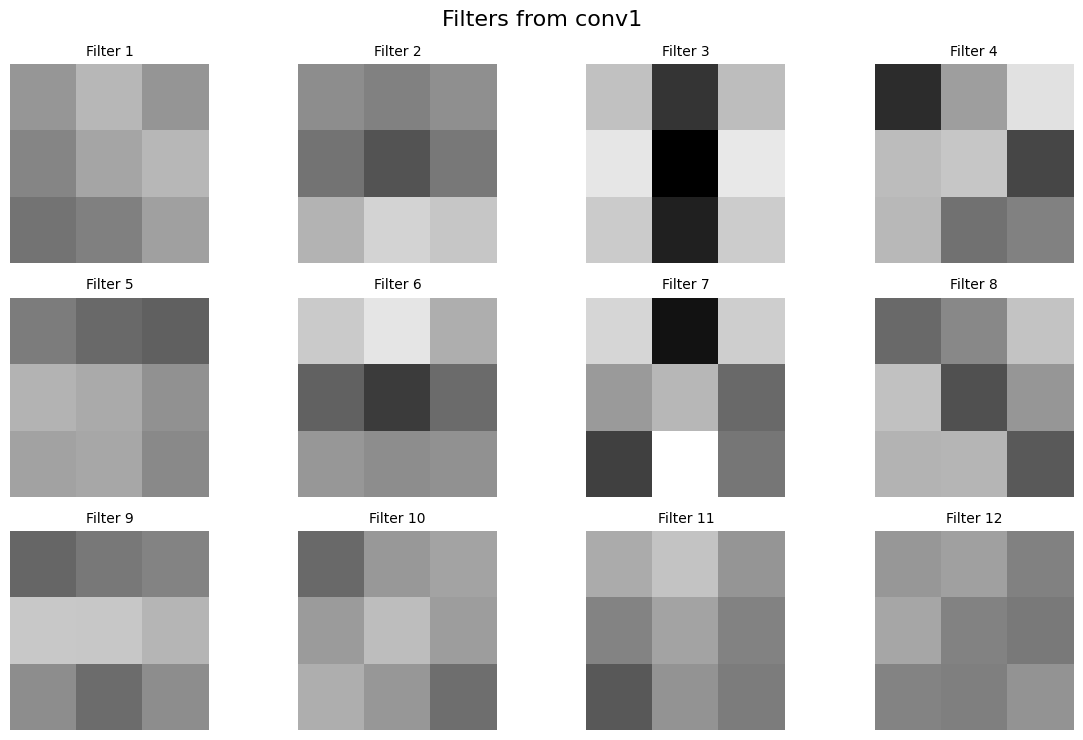

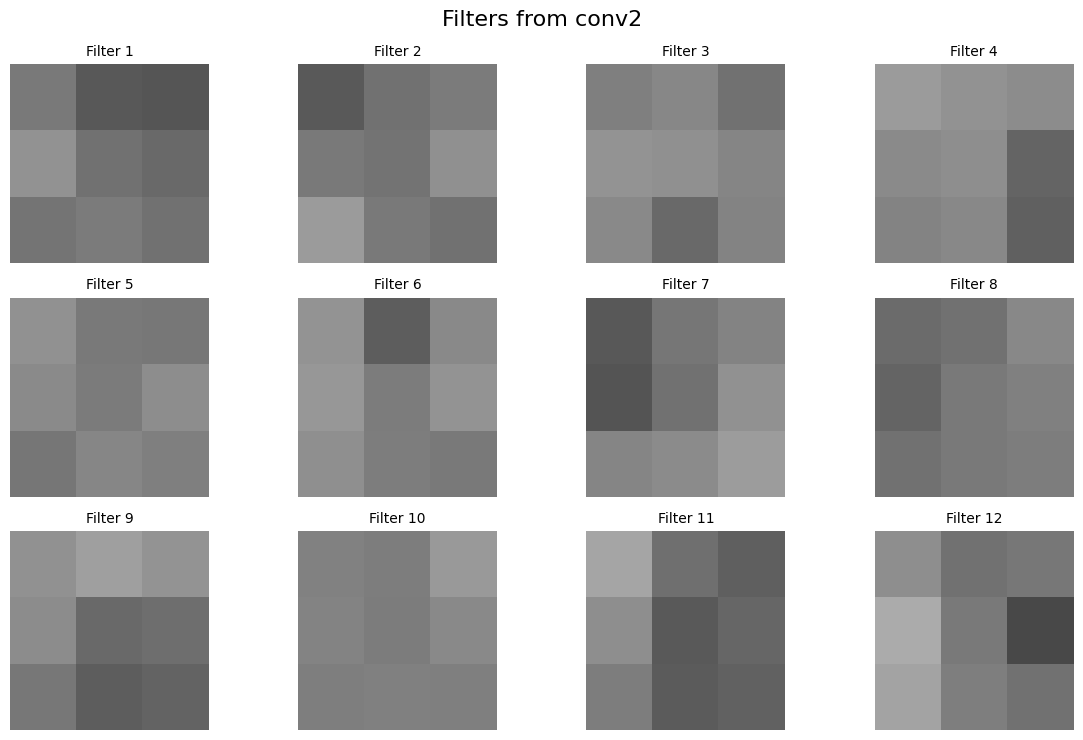

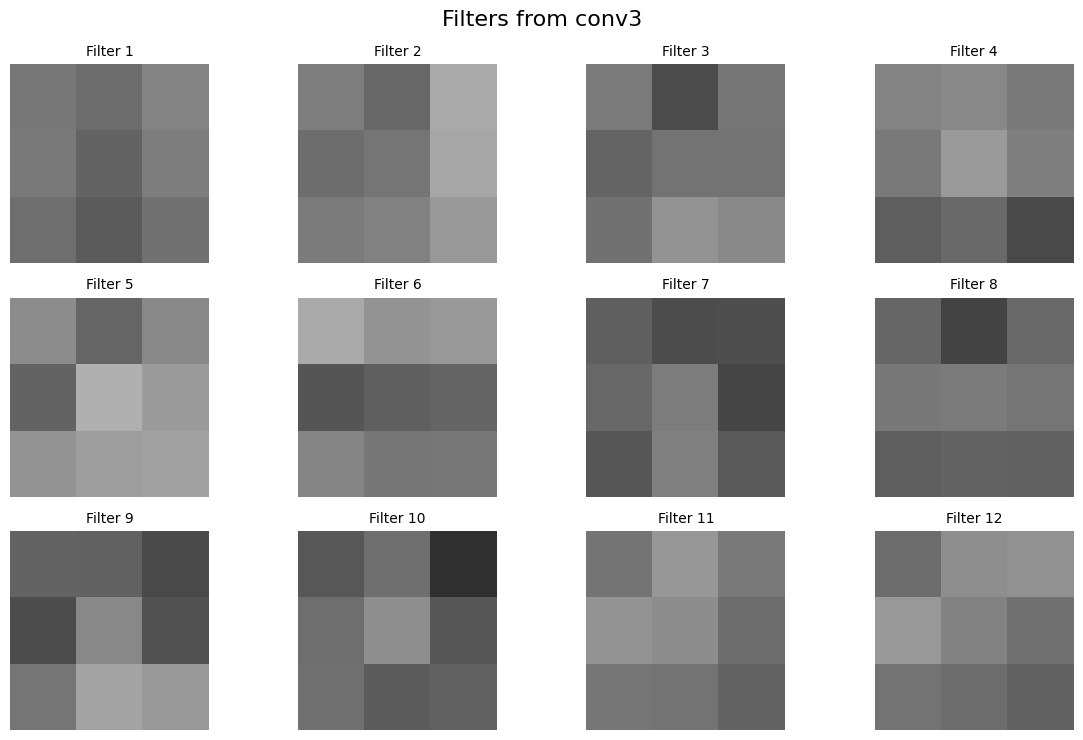

In [12]:
simple_cnn.eval()

# Visualize filters from the first convolutional layer
visualize_filters(simple_cnn, 'conv1', num_filters=12)
visualize_filters(simple_cnn, 'conv2', num_filters=12)
visualize_filters(simple_cnn, 'conv3', num_filters=12)

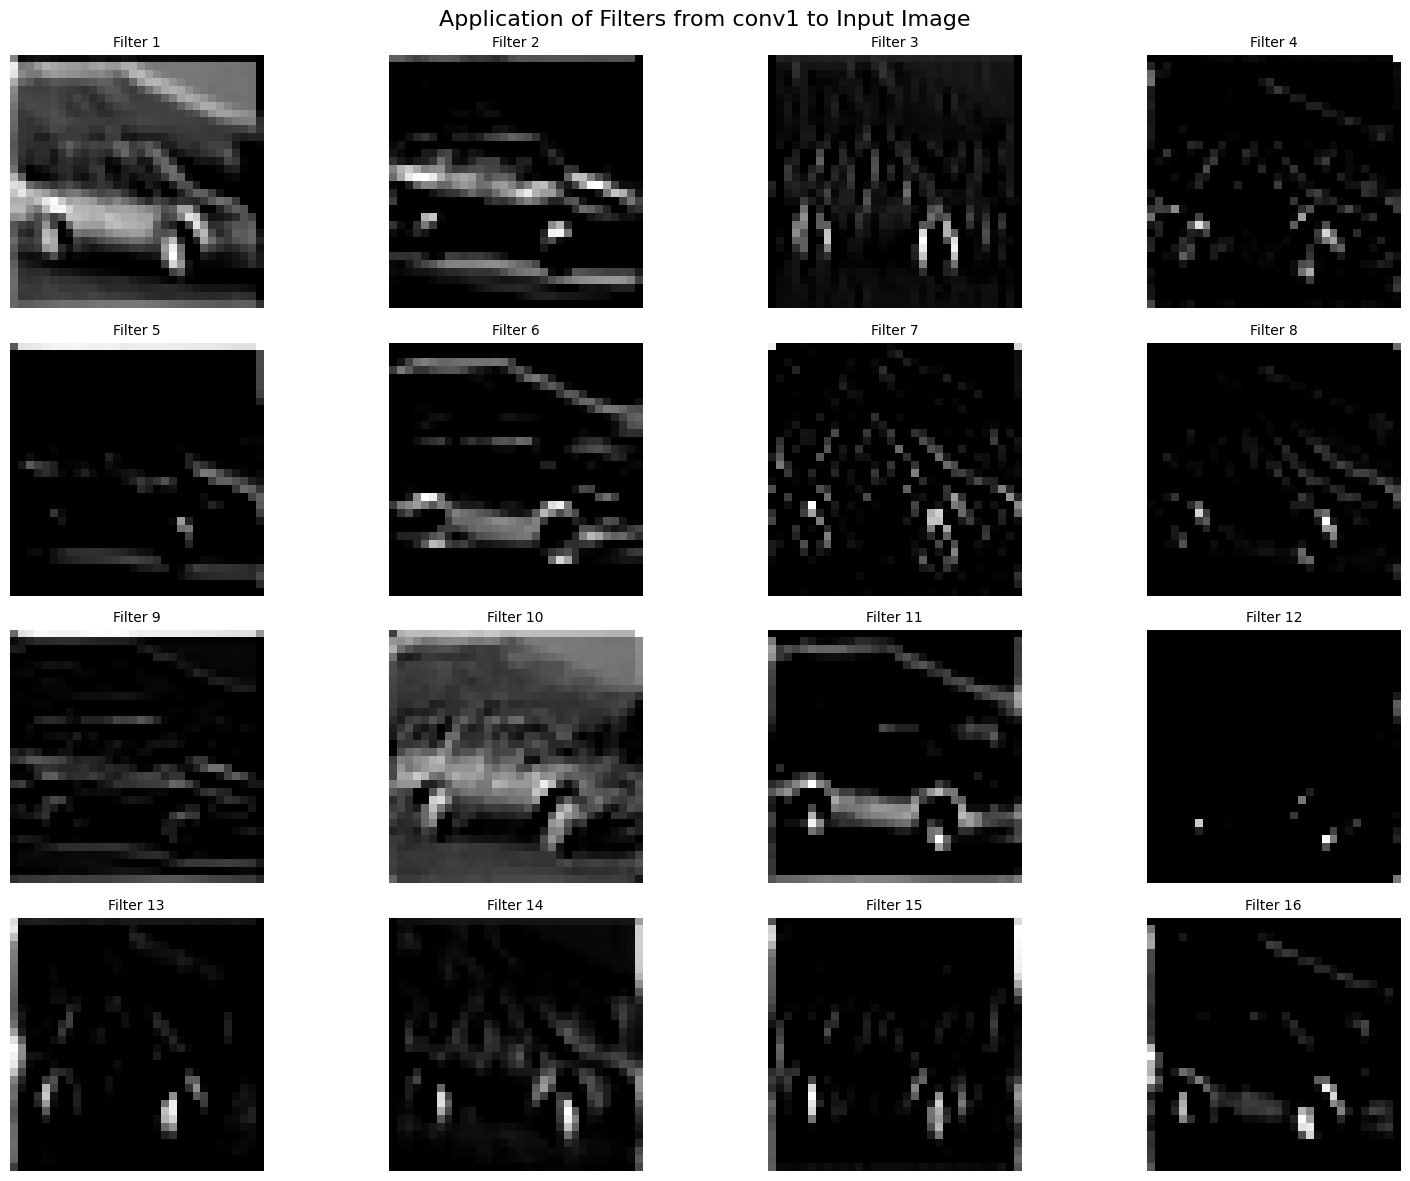

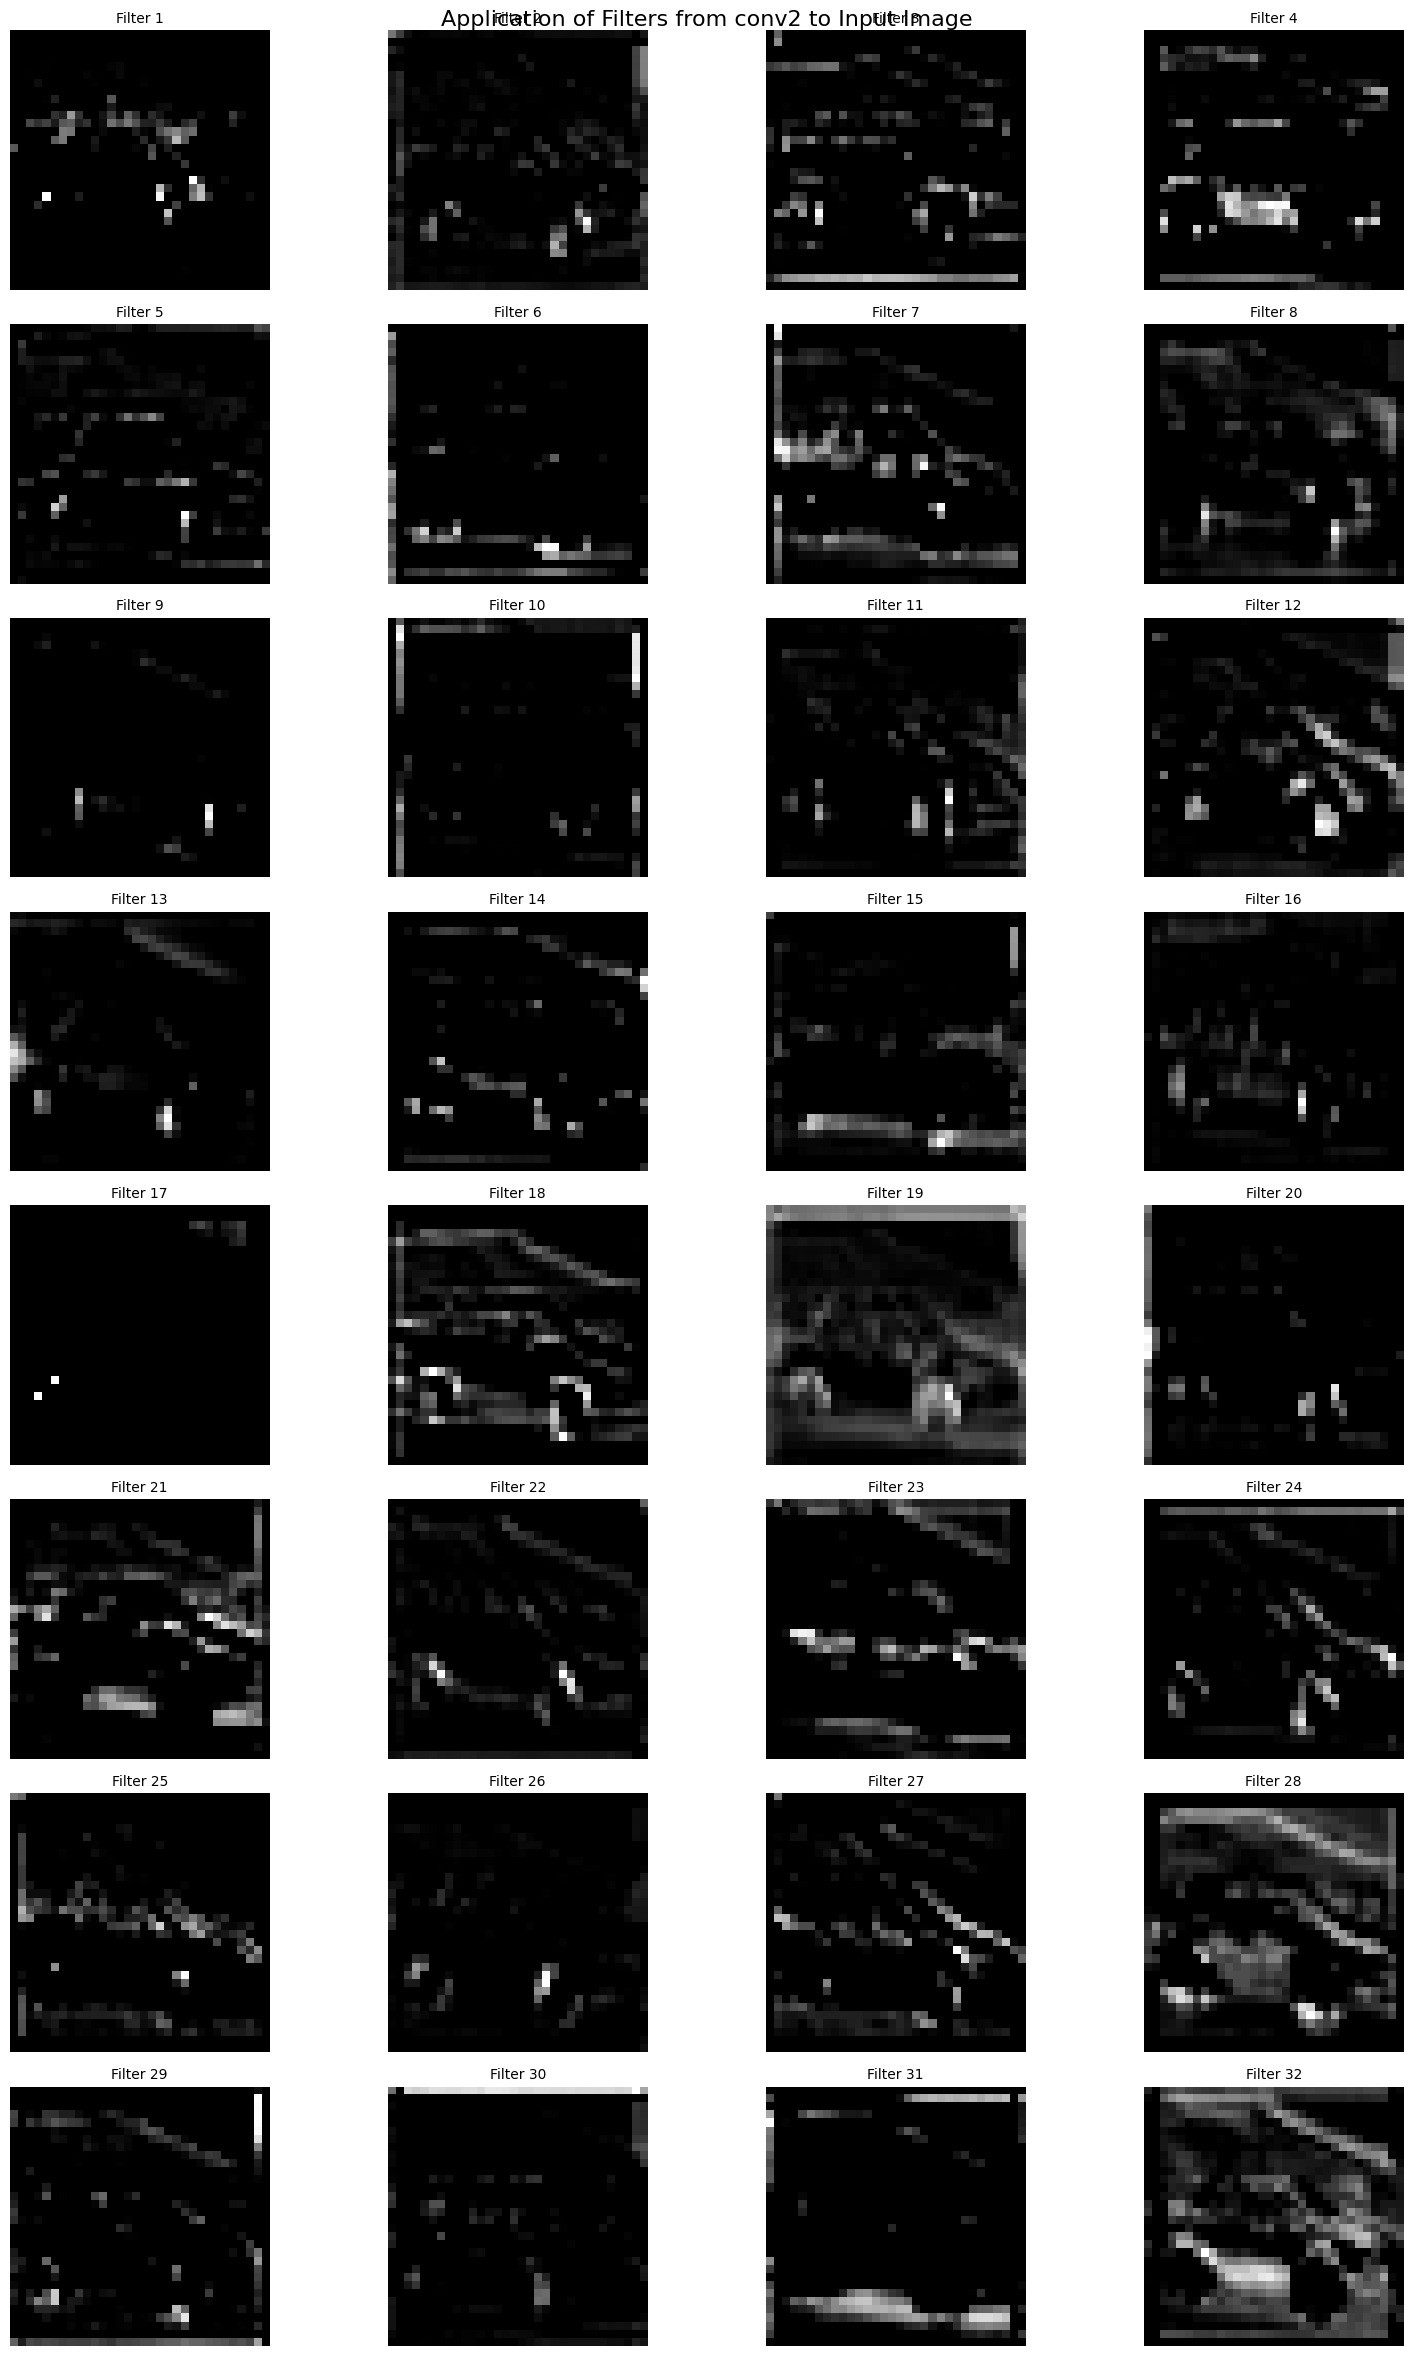

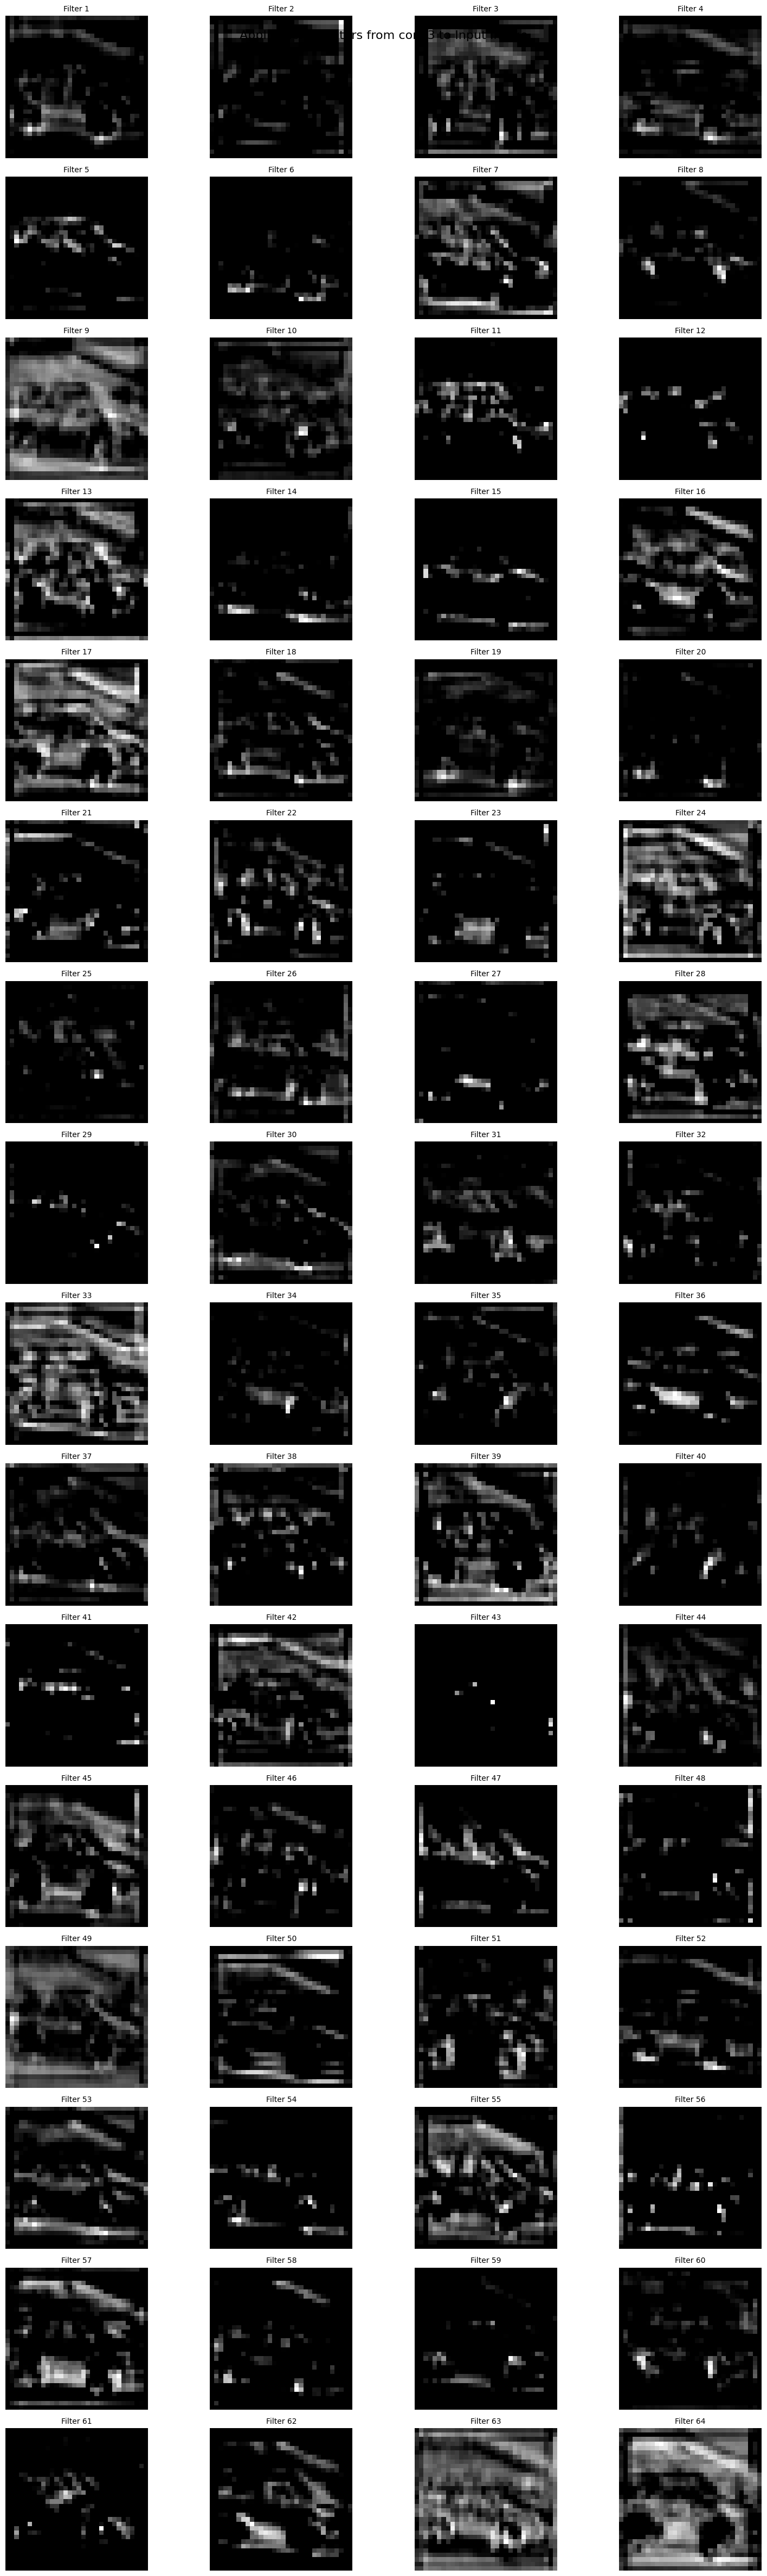

In [13]:
def apply_filters_to_image(model, image, layer_name):
    """
    Apply individual filters from a specific convolutional layer to an input image.

    Parameters:
        - model: The CNN model
        - image: Input image (Tensor with shape [C, H, W] or [N, C, H, W])
        - layer_name: The name of the convolutional layer (e.g., 'conv1', 'conv2', 'conv3')

    Returns:
        None (displays the visualizations)
    """

    # Get the specified convolutional layer
    layer = getattr(model, layer_name)

    # Support Sequential blocks by extracting the first Conv2d module
    if isinstance(layer, nn.Sequential):
        layer = next((m for m in layer if isinstance(m, nn.Conv2d)), None)
        if layer is None:
            raise ValueError(f"No Conv2d layer found in {layer_name}")

    # Get the individual filters
    filters = layer.weight.data

    # Ensure input image has shape [N, C, H, W] and correct dtype/device
    if image.dim() == 3:
        image = image.unsqueeze(0)
    x = image.float().to(filters.device)

    def apply_block(block_name, x_in):
        block = getattr(model, block_name)
        if isinstance(block, nn.Sequential):
            return block(x_in)
        bn = getattr(model, f"bn{block_name[-1]}", None)
        pool = getattr(model, f"pool{block_name[-1]}", None)
        x_out = block(x_in)
        if bn is not None:
            x_out = bn(x_out)
        x_out = F.relu(x_out)
        if pool is not None:
            x_out = pool(x_out)
        return x_out

    # For conv2/conv3, compute the input feature map by running previous blocks
    block_order = ["conv1", "conv2", "conv3"]
    if layer_name in block_order:
        target_idx = block_order.index(layer_name)
        for i in range(target_idx):
            x = apply_block(block_order[i], x)

    # Apply and visualize each filter on the input feature map
    num_filters = filters.shape[0]
    cols = 4  # 4 filters per row
    rows = (num_filters + cols - 1) // cols  # Calculate rows needed
    fig_width = cols * 4  # 4 inches per column
    fig_height = rows * 3  # 3 inches per row
    
    plt.figure(figsize=(fig_width, fig_height))
    for i in range(num_filters):
        output = F.relu(F.conv2d(x, filters[i].unsqueeze(0).float(), padding=1))
        plt.subplot(rows, cols, i + 1)
        plt.imshow(output.squeeze().detach().cpu().numpy(), cmap='gray')
        plt.title(f'Filter {i + 1}', fontsize=10)
        plt.axis('off')

    plt.suptitle(f'Application of Filters from {layer_name} to Input Image', fontsize=16)
    plt.tight_layout()
    plt.show()

    
# Load a single grayscale image
cifar_train = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
sample_image, _ = cifar_train[4]

# Apply and visualize filters
apply_filters_to_image(simple_cnn, sample_image, 'conv1')
apply_filters_to_image(simple_cnn, sample_image, 'conv2')
apply_filters_to_image(simple_cnn, sample_image, 'conv3')

## Questions

**Q4**. How does the basic CNN model performance compare against a MLP based model with comparable number of trainable parameters?
The CNN performes a lot better with a lot less parameters. this is because the spatial orientation of the pixels is also taken into account, while the MLP just determines pixel to pixel realationships.

**Q5**. What happens to the loss from the CNN model compared to the MLP based models?
The loss decreases much more

**Q6**. What can you tell about the learned filters in the first convolutional layer?
It is funny to see that 1 image goes completerly trough, also we see mostly edge and line detection filters

# Step 3: Implement a segmentation model
Let's transition from the CIFAR-10 classification dataset to the VOC2012 segmentation dataset. In this section of the notebook, our attention shifts towards semantic segmentation, where we'll explore techniques for delineating objects within images. Due to computational constraints, we'll be training our model on a CPU basis, necessitating a resize of the images to 32x32 pixels. While this resolution may limit the quality of segmentation results, this exercise serves as a valuable opportunity to grasp the fundamentals of building and enhancing a segmentation model. If you have access to a GPU your own your ofcourse free to try and train a segmentation model on a higher resolution with more epochs and get better results.

In [58]:
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader


# ----- Simple Dataset -----
class SimpleVOCDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None, target_transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.target_transform = target_transform

        self.images = sorted(os.listdir(image_dir))
        self.labels = sorted(os.listdir(label_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.image_dir, self.images[idx])).convert("RGB")
        label = Image.open(os.path.join(self.label_dir, self.labels[idx]))

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            label = self.target_transform(label)

        return image, label


# ----- Transforms -----
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

target_transforms = transforms.Compose([
    transforms.Resize((32, 32), transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])


# ----- Datasets -----
train_dataset = SimpleVOCDataset(
    image_dir="./data/voc-2012-segmentation-data/train_images",
    label_dir="./data/voc-2012-segmentation-data/train_labels",
    transform=transform,
    target_transform=target_transforms
)

val_dataset = SimpleVOCDataset(
    image_dir="./data/voc-2012-segmentation-data/valid_images",
    label_dir="./data/voc-2012-segmentation-data/valid_labels",
    transform=transform,
    target_transform=target_transforms
)


# ----- DataLoaders -----
trainloader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
validationloader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

In [95]:
# create Segmentation model
class DoubleConv(nn.Module):
    """(Conv => BN => ReLU) * 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SegmentationUNetAddSkips(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout_p: float = 0.2):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 16)     # 32x32
        self.pool1 = nn.MaxPool2d(2)                # -> 16x16
        self.enc2 = DoubleConv(16, 32)              # 16x16
        self.pool2 = nn.MaxPool2d(2)                # -> 8x8
        self.enc3 = DoubleConv(32, 64)              # 8x8
        self.pool3 = nn.MaxPool2d(2)                # -> 4x4

        # Bottleneck (with dropout)
        self.bottleneck = nn.Sequential(
            DoubleConv(64, 128),                    # 4x4
            nn.Dropout2d(p=dropout_p),
        )

        # Decoder (upsample + add skip + refine with DoubleConv)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # 4->8
        self.skip1 = nn.Conv2d(64, 64, kernel_size=1)
        self.dec1 = DoubleConv(64, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)   # 8->16
        self.skip2 = nn.Conv2d(32, 32, kernel_size=1)
        self.dec2 = DoubleConv(32, 32)

        self.up3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)   # 16->32
        self.skip3 = nn.Conv2d(16, 16, kernel_size=1)
        self.dec3 = DoubleConv(16, 16)

        # Per-pixel classifier
        self.classifier = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)               # (B,16,32,32)
        x2 = self.enc2(self.pool1(x1))  # (B,32,16,16)
        x3 = self.enc3(self.pool2(x2))  # (B,64,8,8)

        x4 = self.pool3(x3)             # (B,64,4,4)
        xb = self.bottleneck(x4)        # (B,128,4,4)

        # Decoder stage 1: 4->8, add skip from x3
        x = self.up1(xb)                # (B,64,8,8)
        x = x + self.skip1(x3)
        x = self.dec1(x)                # (B,64,8,8)

        # Decoder stage 2: 8->16, add skip from x2
        x = self.up2(x)                 # (B,32,16,16)
        x = x + self.skip2(x2)
        x = self.dec2(x)                # (B,32,16,16)

        # Decoder stage 3: 16->32, add skip from x1
        x = self.up3(x)                 # (B,16,32,32)
        x = x + self.skip3(x1)
        x = self.dec3(x)                # (B,16,32,32)

        logits = self.classifier(x)     # (B,num_classes,32,32)
        return logits

In [ ]:
def train_model_segmentation(model, train_loader, val_loader, num_epochs=5, lr=0.01, num_classes=21):
    criterion = nn.CrossEntropyLoss(ignore_index=255)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, threshold=1e-3
    )

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, masks in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)

            # Masks are already 0-255 from PILToTensor; squeeze channel to [B, H, W]
            masks = masks.long().squeeze(1)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # Validation metrics
        model.eval()
        correct_pixels = 0
        total_pixels = 0
        intersection = torch.zeros(num_classes, dtype=torch.float64)
        union = torch.zeros(num_classes, dtype=torch.float64)
        val_running_loss = 0.0
        with torch.no_grad():
            for inputs, masks in val_loader:
                outputs = model(inputs)
                masks = masks.long().squeeze(1)
                val_loss = criterion(outputs, masks)
                val_running_loss += val_loss.item()

                preds = torch.argmax(outputs, dim=1)
                valid = masks != 255
                correct_pixels += (preds[valid] == masks[valid]).sum().item()
                total_pixels += valid.sum().item()

                for cls in range(num_classes):
                    pred_c = (preds == cls) & valid
                    mask_c = (masks == cls) & valid
                    intersection[cls] += (pred_c & mask_c).sum().item()
                    union[cls] += (pred_c | mask_c).sum().item()

        val_loss = val_running_loss / len(val_loader)
        pixel_acc = 100.0 * correct_pixels / max(1, total_pixels)
        iou = intersection / torch.clamp(union, min=1.0)
        miou = torch.mean(iou).item() * 100.0
        scheduler.step(val_loss)
        print(
            f"Epoch {epoch + 1}/{num_epochs}, "
            f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
            f"Val Pixel Acc: {pixel_acc:.2f}%, Val mIoU: {miou:.2f}%"
        )

Unfortunately, this training process takes slightly longer compared to earlier training loops (+- 30 min for 30 epochs). However, it's worthwhile to take some time to consider potential optimizations that could enhance its speed.

In [97]:
nb_epochs = 40
learning_rate = 0.001

segmentation_model = SegmentationUNetAddSkips(in_channels=3, num_classes=21)

train_model_segmentation(segmentation_model, trainloader, nb_epochs, learning_rate)

Epoch 1/40, Loss: 1.9732
Epoch 2/40, Loss: 1.2475
Epoch 3/40, Loss: 1.1951
Epoch 4/40, Loss: 1.1735
Epoch 5/40, Loss: 1.1585
Epoch 6/40, Loss: 1.1381
Epoch 7/40, Loss: 1.1162
Epoch 8/40, Loss: 1.0936
Epoch 9/40, Loss: 1.0882
Epoch 10/40, Loss: 1.0567
Epoch 11/40, Loss: 1.0399
Epoch 12/40, Loss: 1.0237
Epoch 13/40, Loss: 0.9992
Epoch 14/40, Loss: 0.9773
Epoch 15/40, Loss: 0.9582
Epoch 16/40, Loss: 0.9381
Epoch 17/40, Loss: 0.9286
Epoch 18/40, Loss: 0.9012
Epoch 19/40, Loss: 0.8851
Epoch 20/40, Loss: 0.8730
Epoch 21/40, Loss: 0.8467
Epoch 22/40, Loss: 0.8398
Epoch 23/40, Loss: 0.8157
Epoch 24/40, Loss: 0.7827
Epoch 25/40, Loss: 0.7755
Epoch 26/40, Loss: 0.7593
Epoch 27/40, Loss: 0.7419
Epoch 28/40, Loss: 0.7211
Epoch 29/40, Loss: 0.6892
Epoch 30/40, Loss: 0.6759
Epoch 31/40, Loss: 0.6600
Epoch 32/40, Loss: 0.6447
Epoch 33/40, Loss: 0.6296
Epoch 34/40, Loss: 0.6197
Epoch 35/40, Loss: 0.5992
Epoch 36/40, Loss: 0.5632
Epoch 37/40, Loss: 0.5602
Epoch 38/40, Loss: 0.5392
Epoch 39/40, Loss: 0.

In [99]:
# visualize examples (No modifications needed)
colors = {
        0: (0, 0, 0),
        1: (31, 119, 180),
        2: (255, 127, 14),  
        3: (44, 160, 44),   
        4: (214, 39, 40), 
        5: (148, 103, 189),
        6: (140, 86, 75),
        7: (227, 119, 194),
        8: (127, 127, 127),
        9: (188, 189, 34),
        10: (23, 190, 207),
        11: (174, 199, 232),
        12: (255, 187, 120),
        13: (152, 223, 138),
        14: (255, 152, 150),
        15: (197, 176, 213),
        16: (196, 156, 148),
        17: (247, 182, 210),
        18: (199, 199, 199),
        19: (219, 219, 141),
        255: (0, 0, 0)
}

class_names = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car',
    'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
 ]

def mask_to_rgb(mask, class_to_color):
    """
    Converts a numpy mask with multiple classes indicated by integers to a color RGB mask.

    Parameters:
        mask (numpy.ndarray): The input mask where each integer represents a class.
        class_to_color (dict): A dictionary mapping class integers to RGB color tuples.

    Returns:
        numpy.ndarray: RGB mask where each pixel is represented as an RGB tuple.
    """
    # Get dimensions of the input mask
    height, width = mask.shape

    # Initialize an empty RGB mask
    rgb_mask = np.zeros((height, width, 3), dtype=np.uint8)

    # Iterate over each class and assign corresponding RGB color
    for class_idx, color in class_to_color.items():
        # Mask pixels belonging to the current class
        class_pixels = mask == class_idx
        # Assign RGB color to the corresponding pixels
        rgb_mask[class_pixels] = color

    return rgb_mask

def visualize_segmentation(model, dataloader, num_examples=5):
    """
    Visualizes segmentation results from a given model using a dataloader.

    Args:
        model (torch.nn.Module): The segmentation model to visualize.
        dataloader (torch.utils.data.DataLoader): Dataloader providing image-mask pairs.
        num_examples (int, optional): Number of examples to visualize. Defaults to 5.

    Returns:
        None
    """
    model.eval()
    with torch.no_grad():
        for i, (images, masks) in enumerate(dataloader):
            if i >= num_examples:
                break
            
            outputs = model(images)
            outputs = torch.softmax(outputs, dim=1)
            predicted = torch.argmax(outputs, 1)

            images = images.numpy()
            masks = masks.numpy()

            predicted = predicted.numpy()

            for j in range(images.shape[0]):
                image = renormalize_image(images[j].transpose(1, 2, 0))

                mask = masks[j].squeeze()
                pred_mask = predicted[j]
                                
                # Convert mask and predicted mask to RGB for visualization
                mask_rgb = mask_to_rgb(mask, colors)
                pred_mask_rgb = mask_to_rgb(pred_mask, colors)
                
                # Get unique classes present in the ground truth and predicted masks
                unique_classes_gt = np.unique(mask)
                unique_classes_pred = np.unique(pred_mask)
                
                unique_classes_gt = unique_classes_gt[(unique_classes_gt != 0) & (unique_classes_gt != 255)]
                unique_classes_pred = unique_classes_pred[unique_classes_pred != 0]
                
                # Map class indices to class names from the VOC2012 dataset
                classes_gt = [class_names[int(idx)] for idx in unique_classes_gt]
                classes_pred = [class_names[int(idx)] for idx in unique_classes_pred]
                
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 3, 1)
                plt.imshow(image)
                plt.title('Image')
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(mask_rgb)
                plt.title(f'Ground Truth Mask Classes:\n {classes_gt}')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(pred_mask_rgb)
                plt.title(f'Predicted Mask Predicted Classes:\n {classes_pred}')
                plt.axis('off')

                plt.show()
                

def renormalize_image(image):
    """
    Renormalizes the image to its original range.
    
    Args:
        image (numpy.ndarray): Image tensor to renormalize.
    
    Returns:
        numpy.ndarray: Renormalized image tensor.
    """
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]  
    renormalized_image = image * std + mean
    return renormalized_image

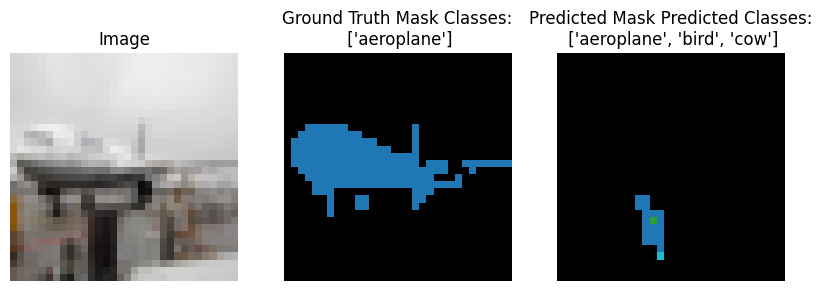

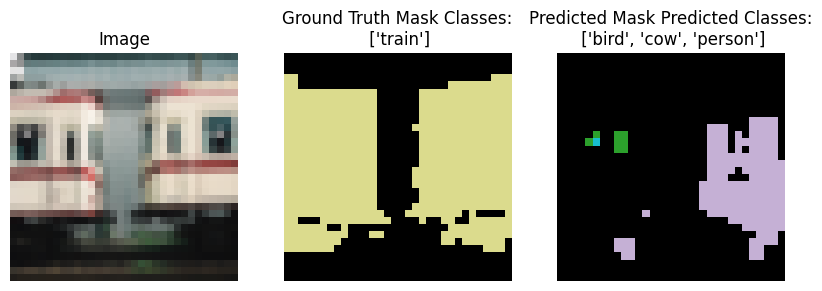

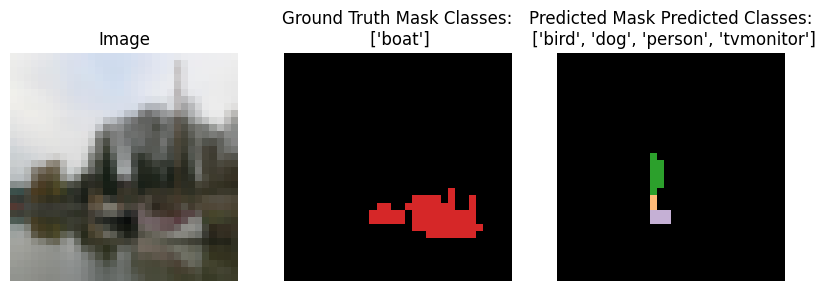

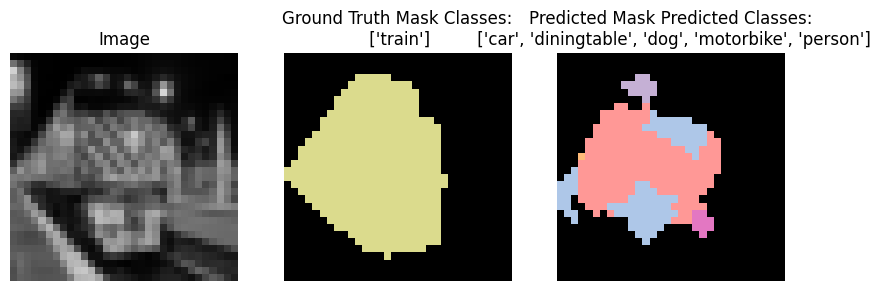

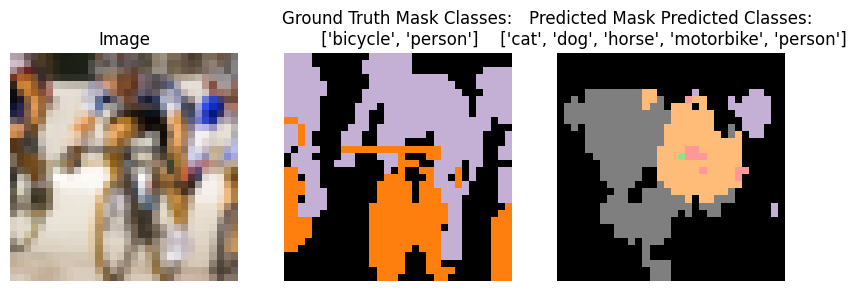

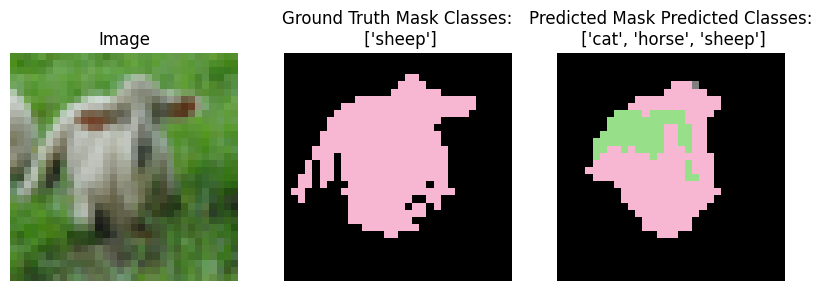

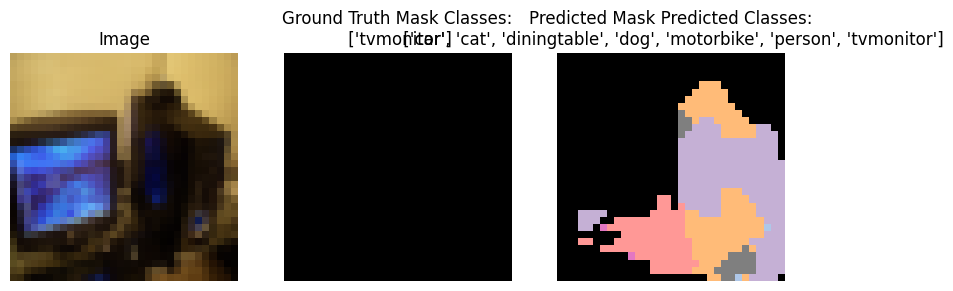

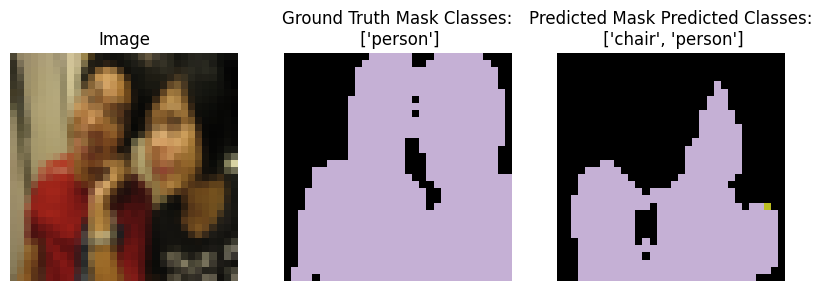

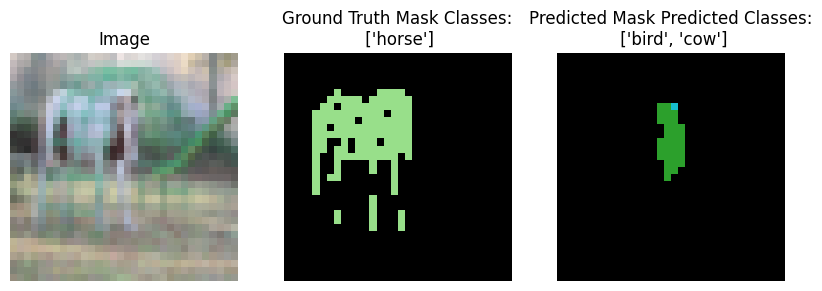

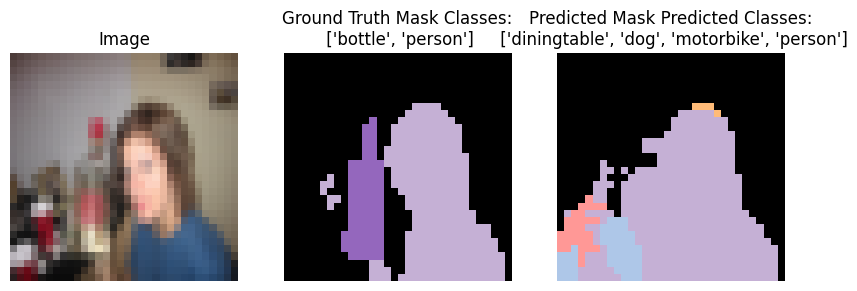

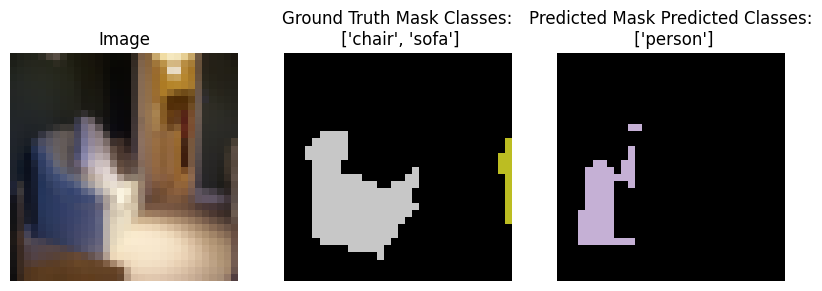

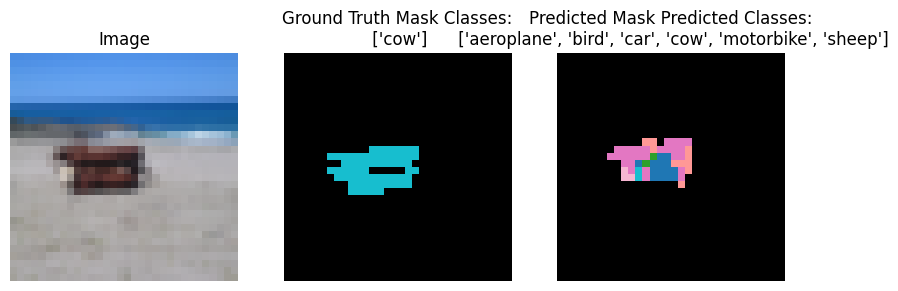

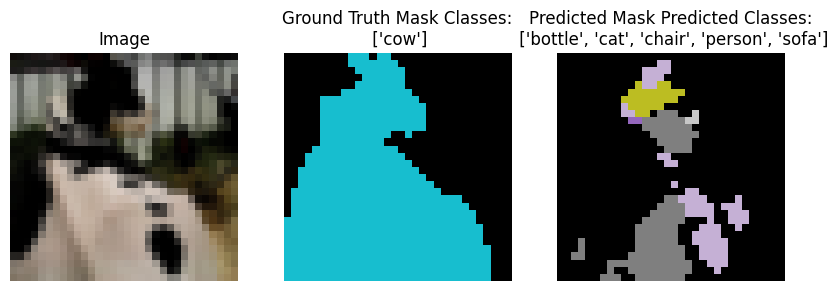

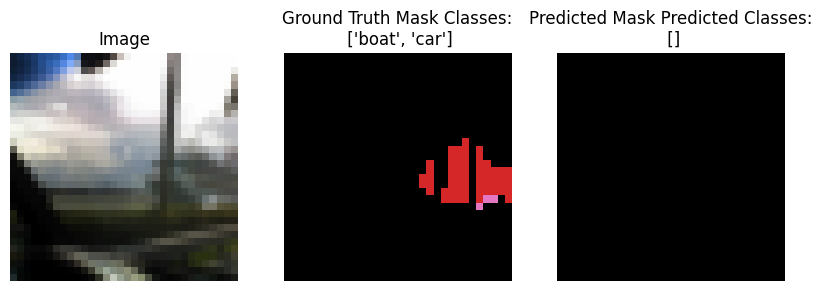

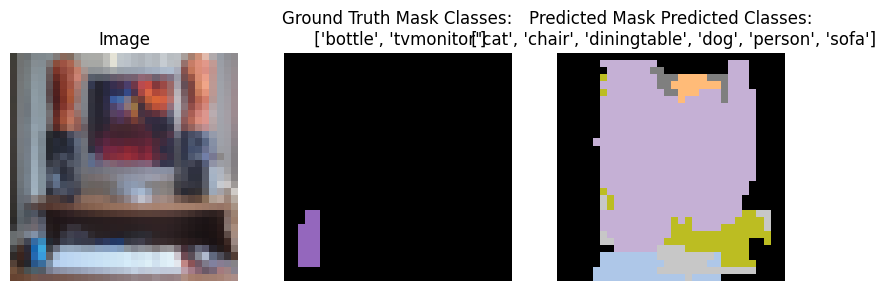

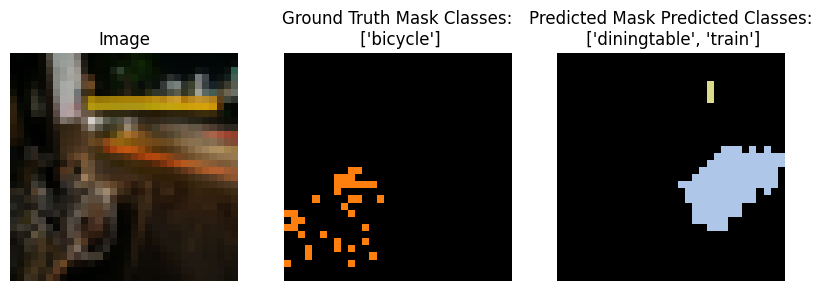

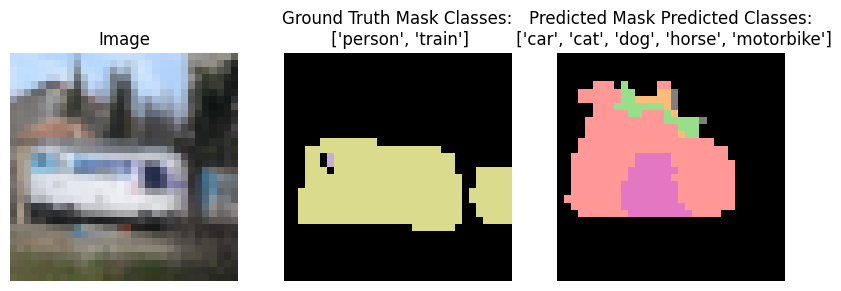

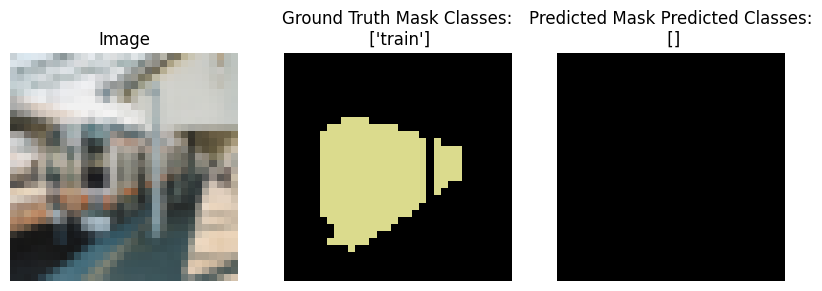

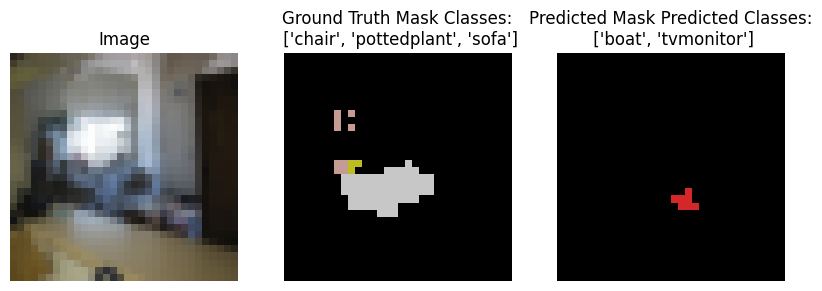

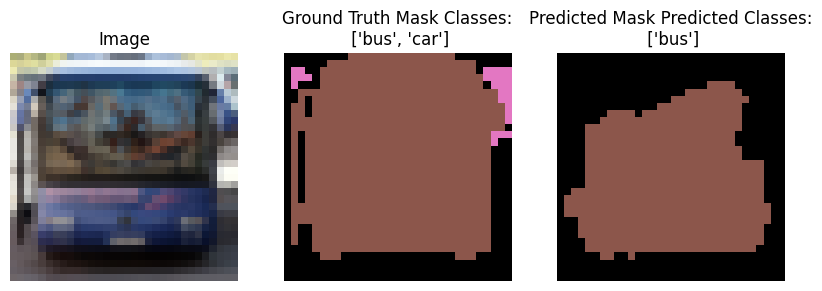

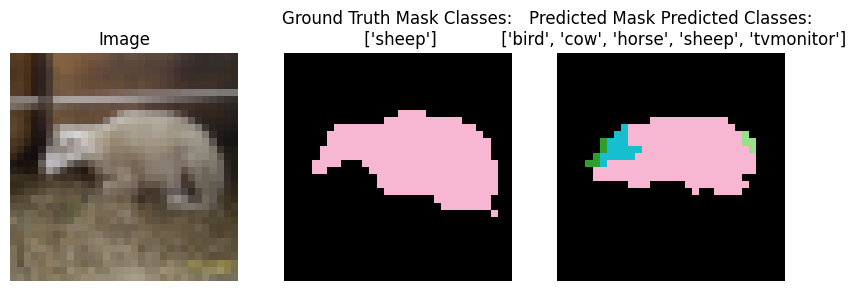

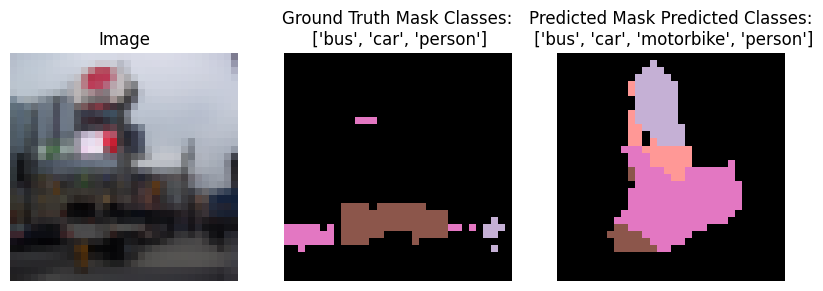

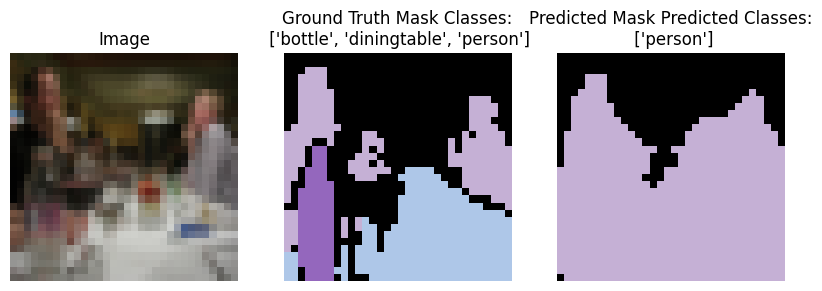

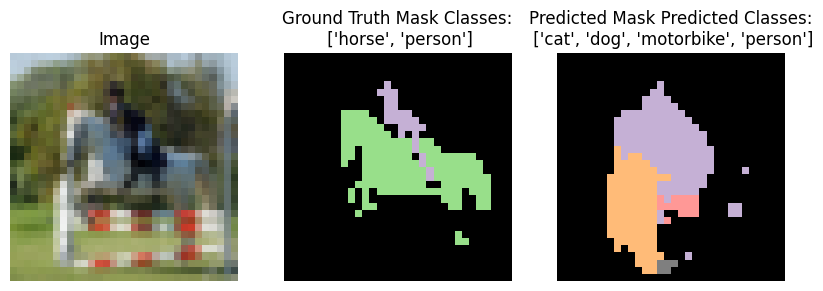

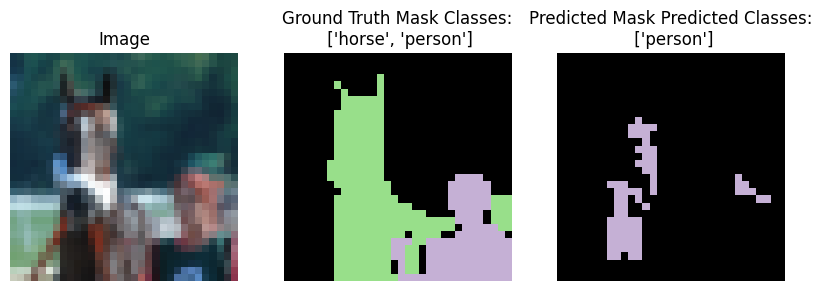

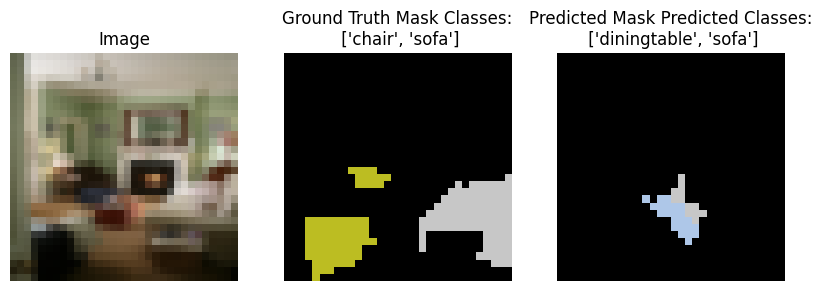

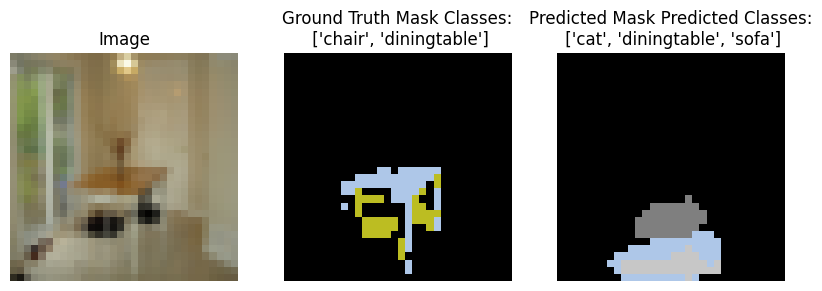

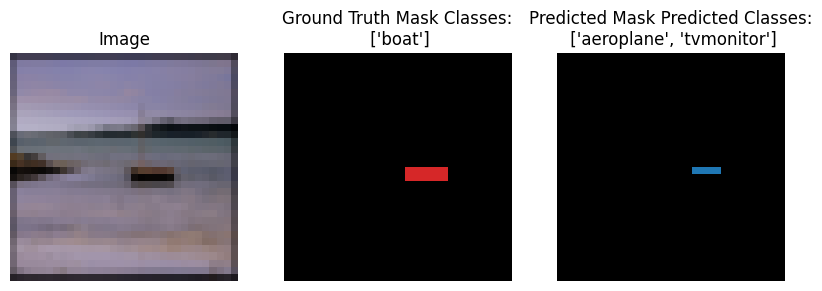

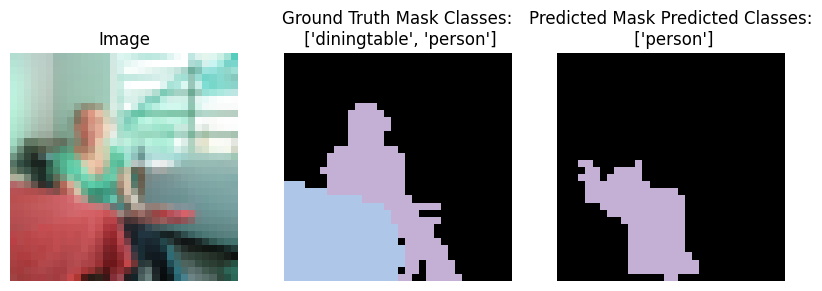

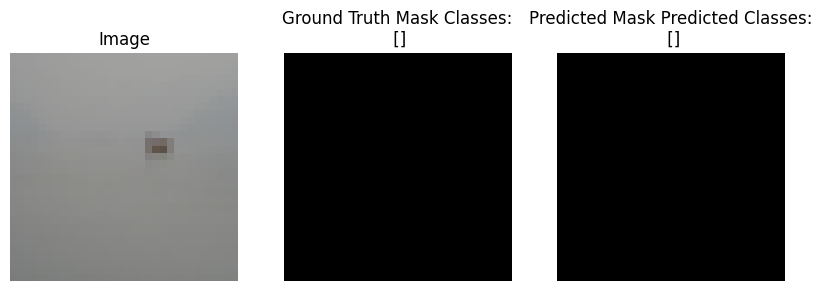

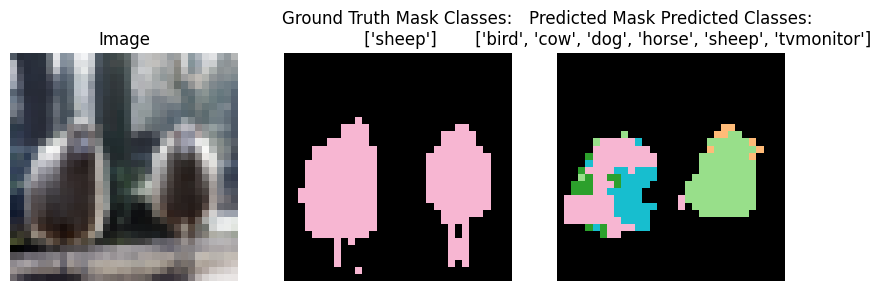

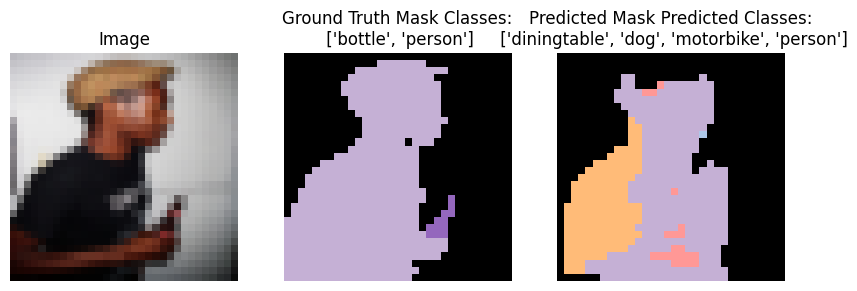

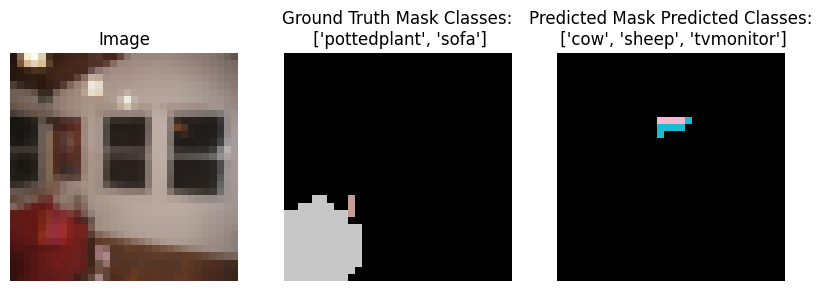

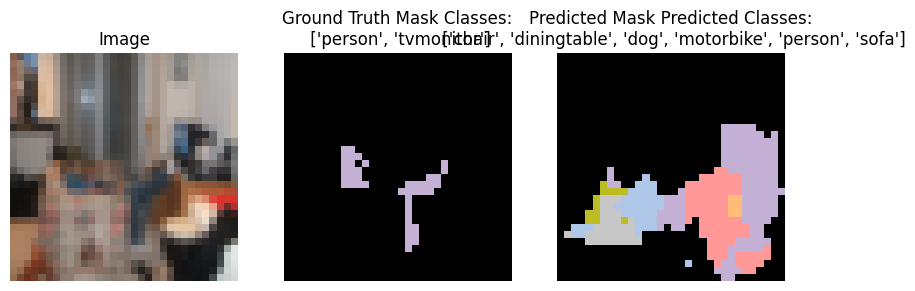

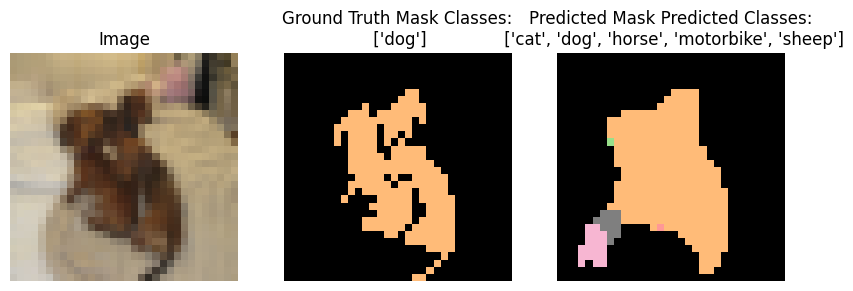

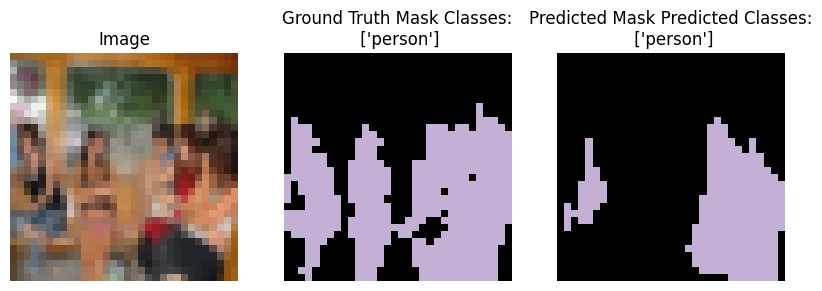

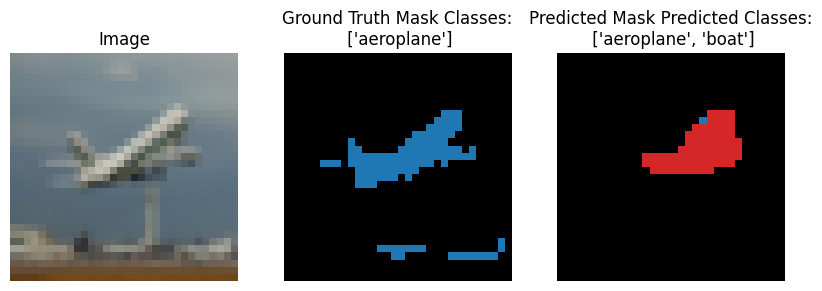

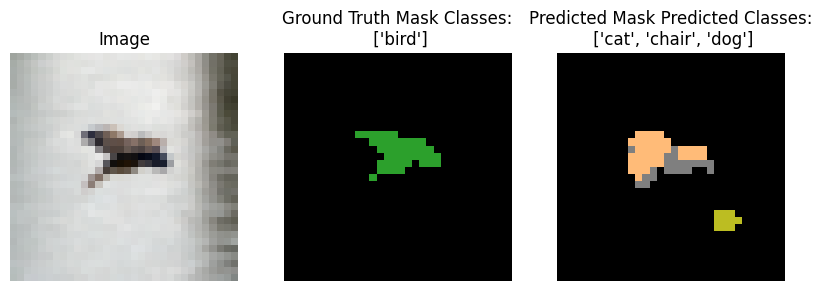

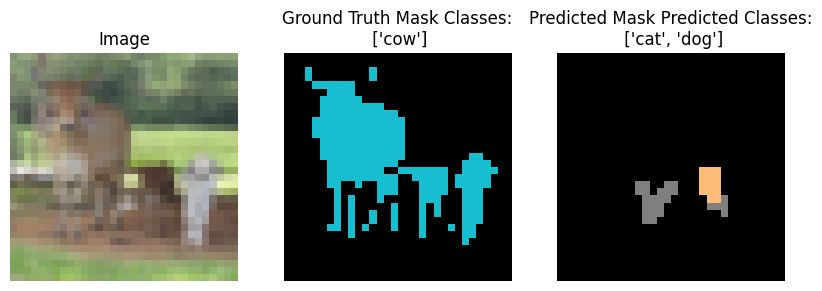

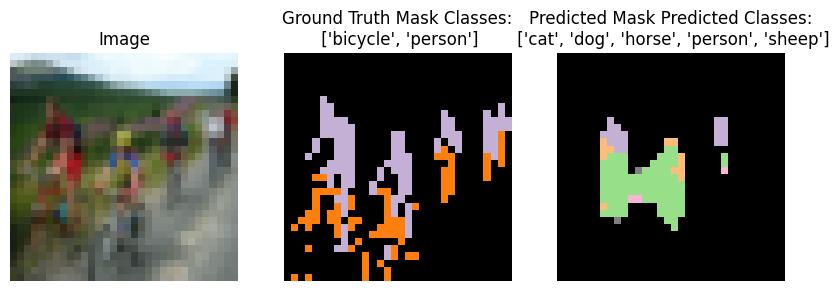

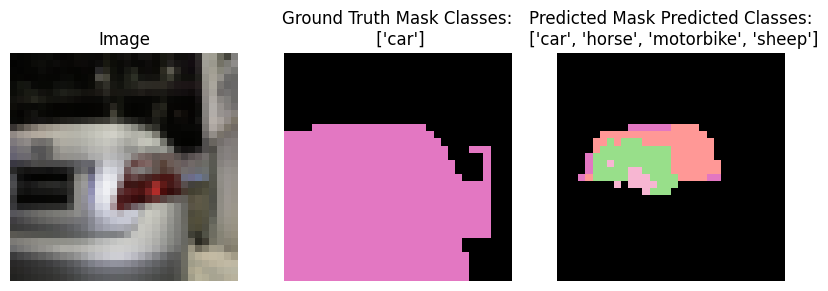

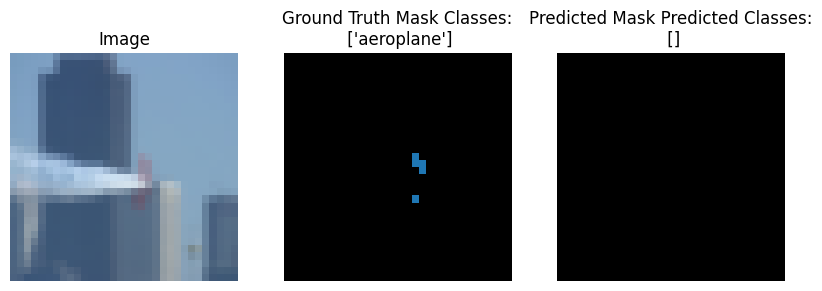

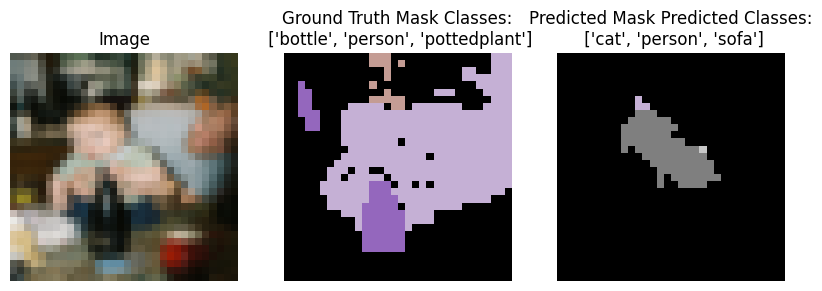

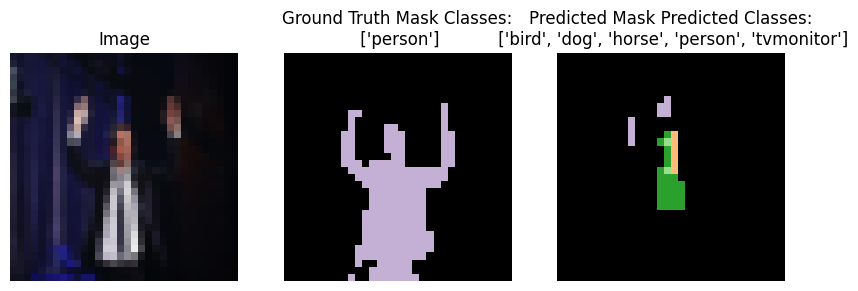

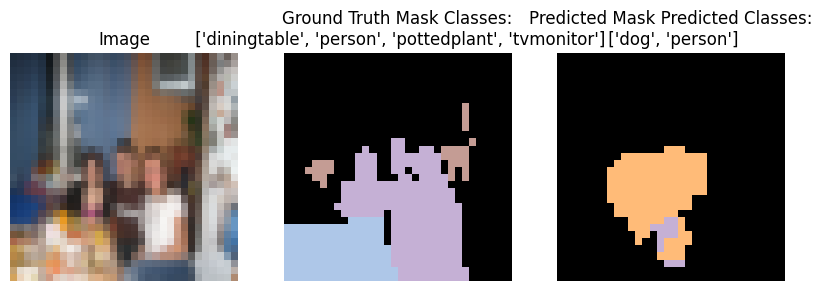

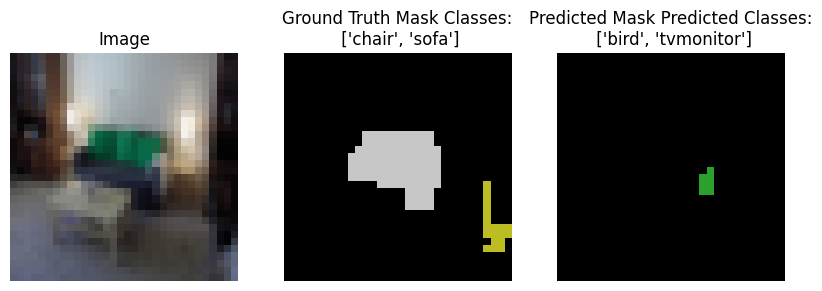

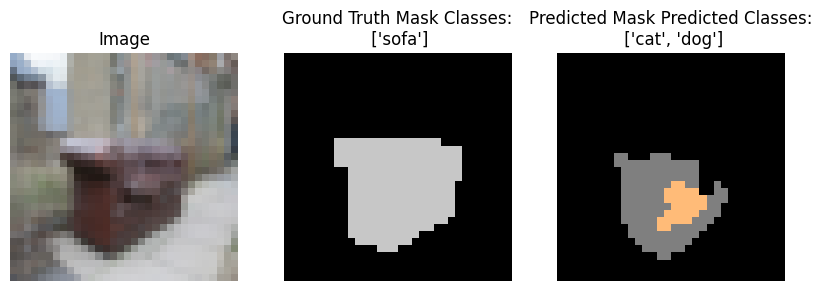

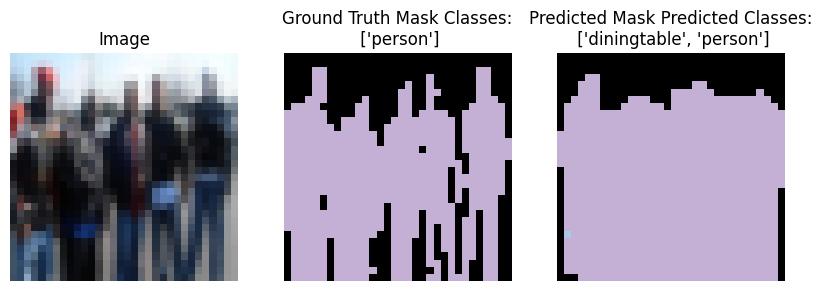

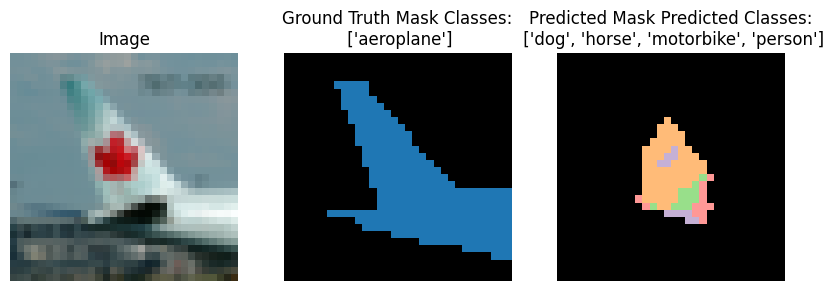

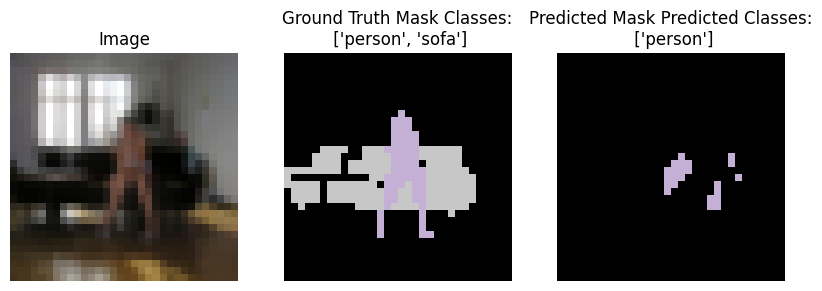

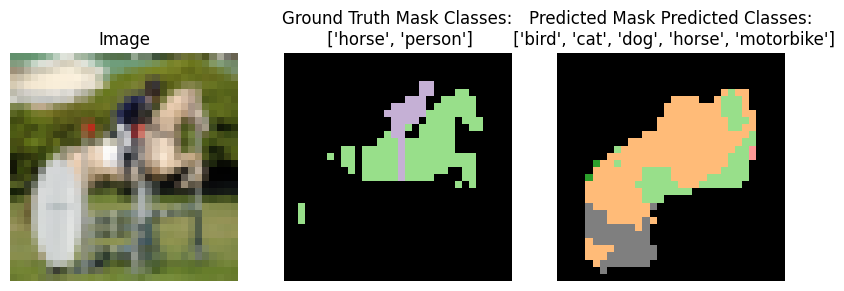

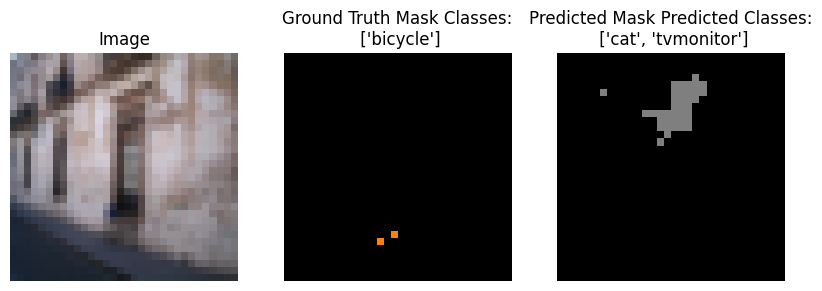

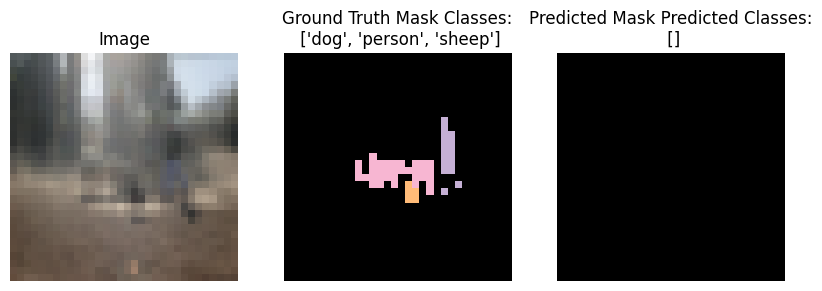

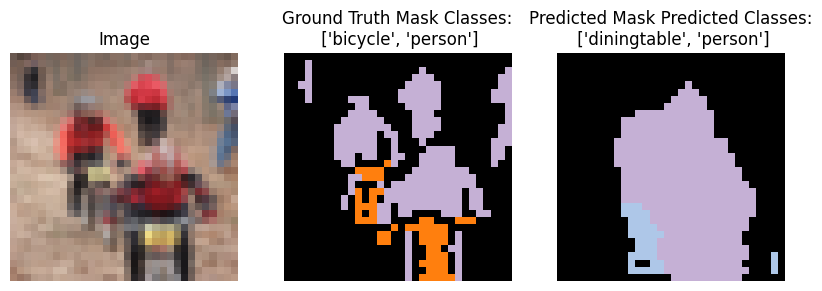

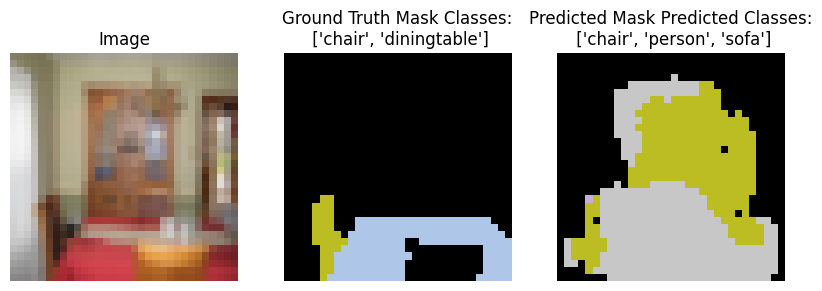

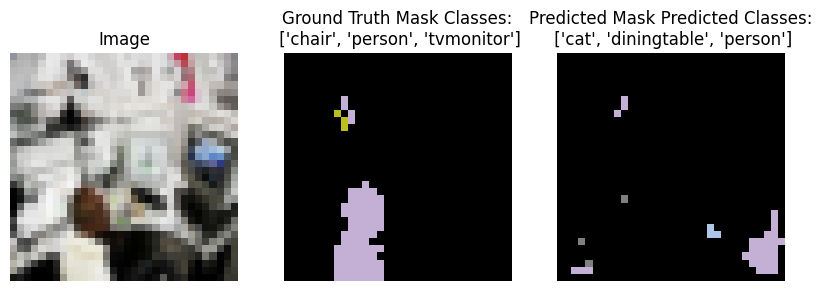

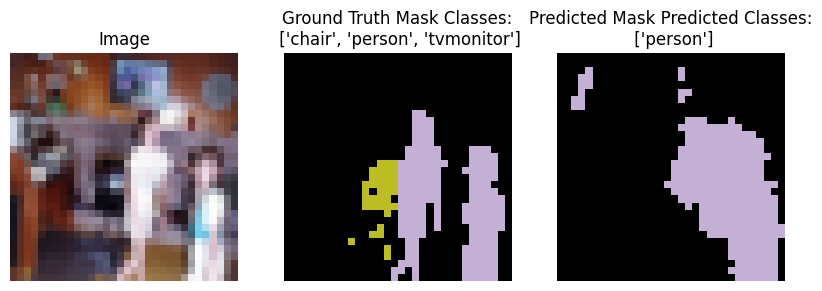

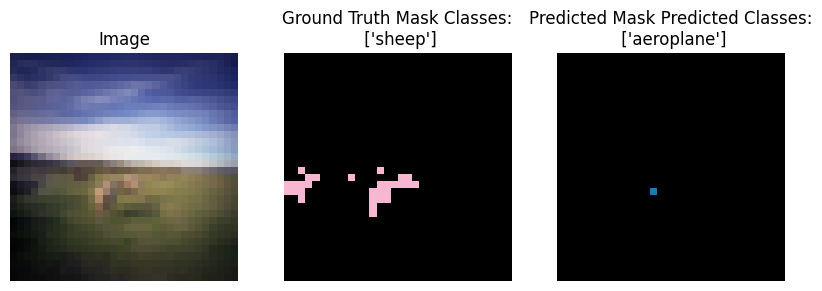

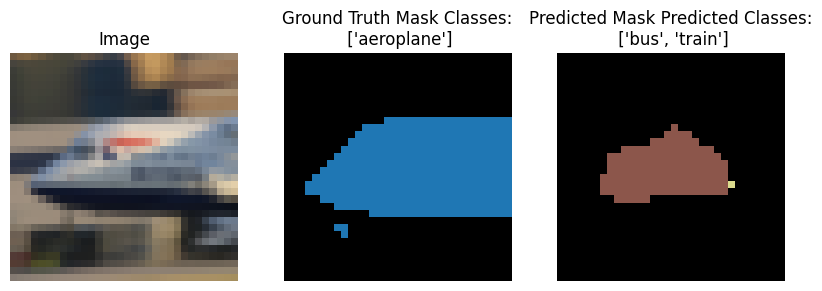

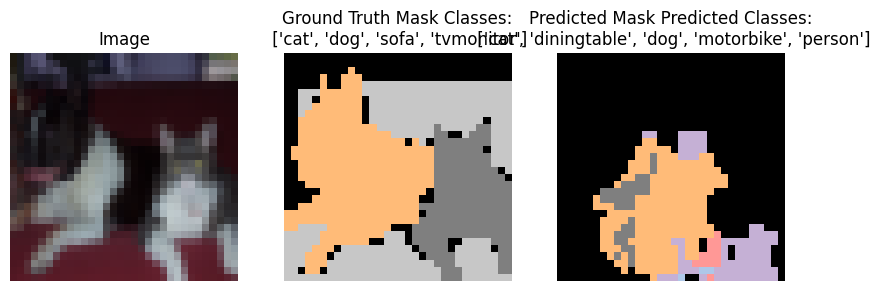

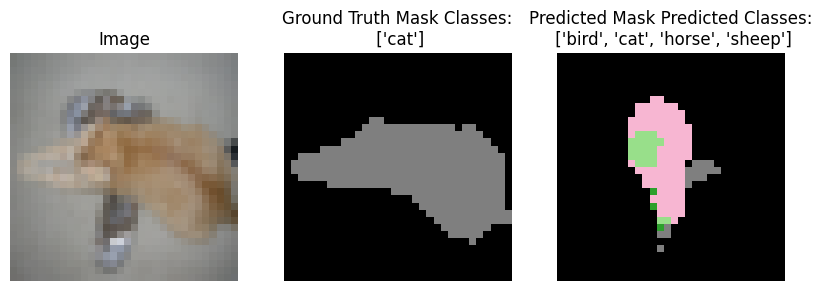

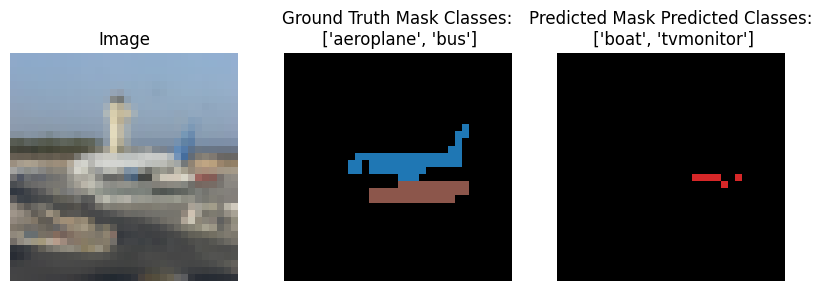

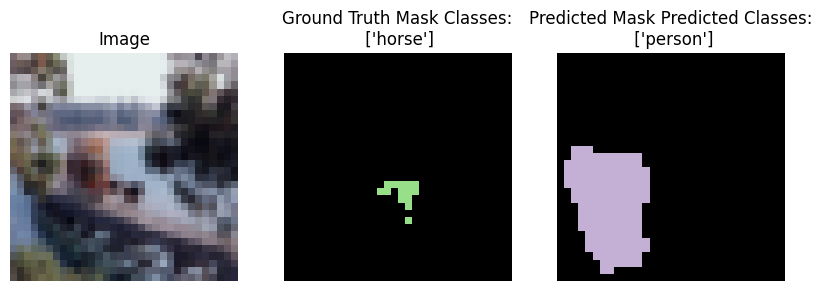

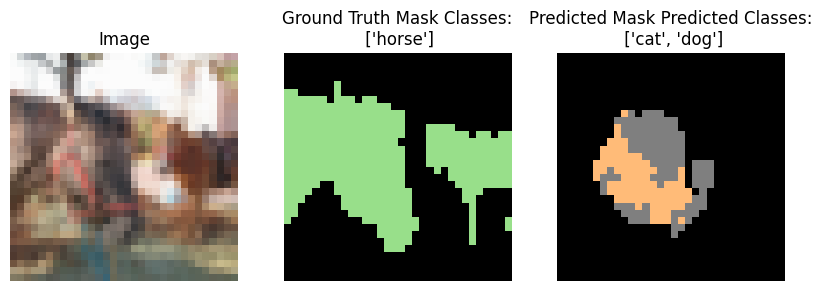

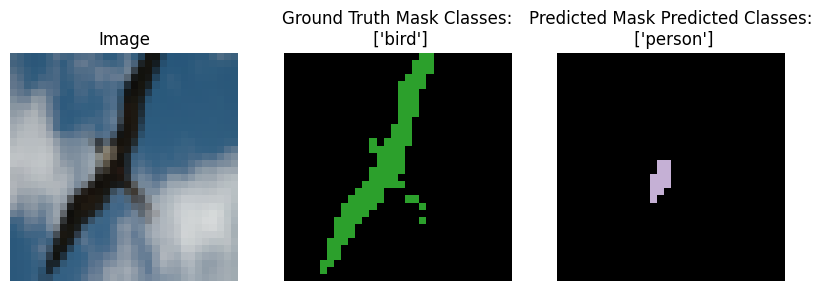

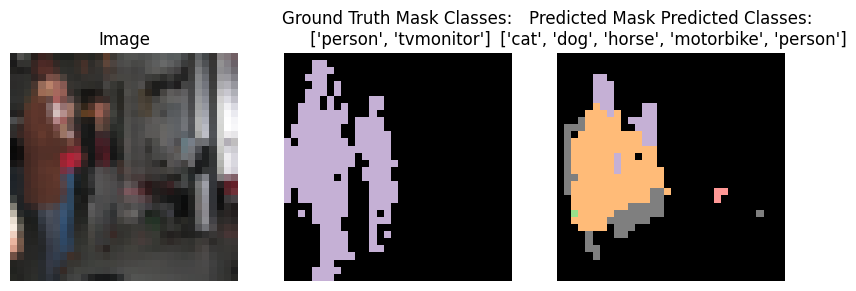

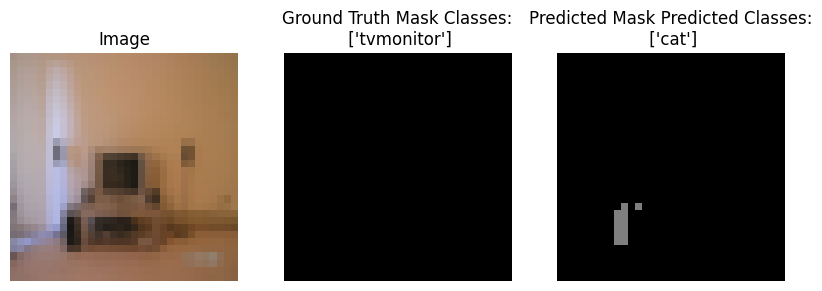

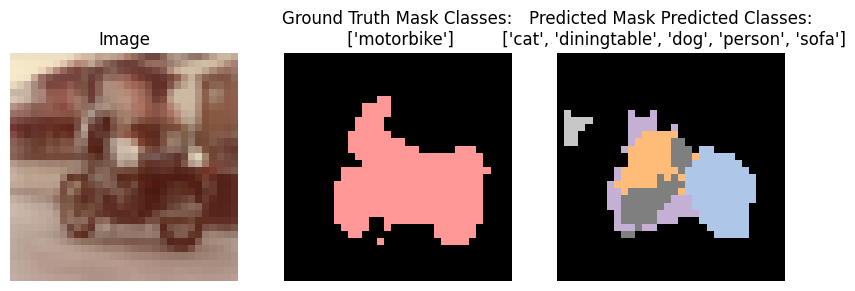

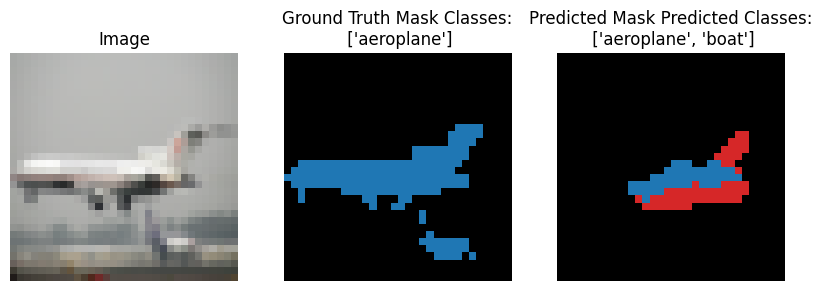

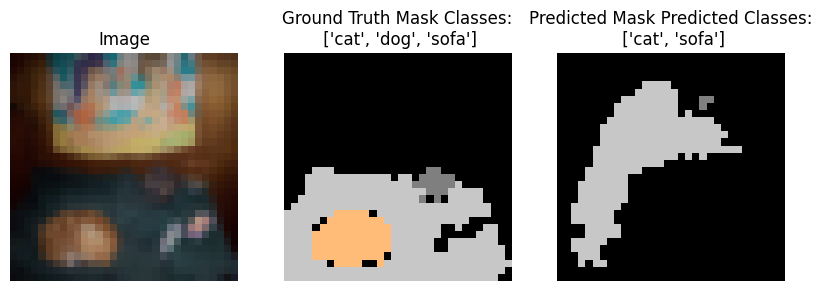

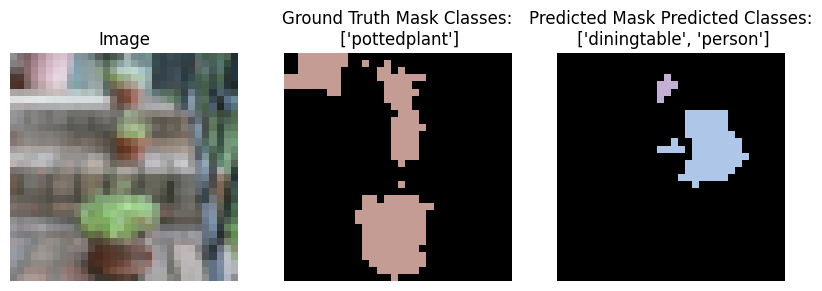

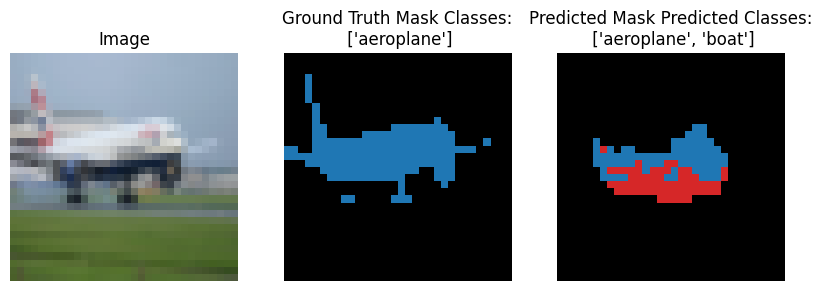

In [101]:
# Think about results
visualize_segmentation(segmentation_model, validationloader, num_examples=9)

# Questions

**Q7**. Which specific modifications or enhancements were implemented to improve the performance of the model?

**Q8**. What are the primary challenges or obstacles encountered by the model when addressing the segmentation problem, and what possible solution can we use to tackle these challenges? Think about the classes the model already segmentens correctly and which classes are misted completely.